## Setting things up

### Import libraries
Add directory with the CIBUSmod modules to path to be able to import

In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(),'..'))

Import CIBUSmod and packages for handling data and plotting

In [2]:
import CIBUSmod as cm
import CIBUSmod.utils.plot as plot

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Set up session

Instantiate a `Session` with a `name` and `data_path` to the folder with input data. Next add scenarios to run with `.add_scenario()`, in this case we only use default data by setting `scenario` to `None`

In [3]:
# Create session
session = cm.Session(
    name = 'base_year',
    data_path = '../data'
)

# Add scenarios
session.add_scenario(
    name = 'base year',
    scenario_workbooks = None,
    years = '2020'
)

# Add scenarios
session.add_scenario(
    name = 'base year (x0 crop areas)',
    scenario_workbooks = None,
    years = '2020'
)

session.add_scenario(
    name = 'base year (sp=0.2)',
    scenario_workbooks = None,
    years = '2020'
)

session.add_scenario(
    name = 'base year (sp=0.8)',
    scenario_workbooks = None,
    years = '2020'
)

A scenario with the name 'base year' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'base year (x0 crop areas)' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'base year (sp=0.2)' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'base year (sp=0.8)' already exists use .update_scenario() or .remove_scenario() instead.


## Instantiate modules and run model

In [26]:
%%time
# Instatiate Regions
regions = cm.Regions(
    par = cm.ParameterRetriever('Regions')
)

# Instantiate DemandAndConversions
demand = cm.DemandAndConversions(
    par = cm.ParameterRetriever('DemandAndConversions')
)

# Instantiate CropProduction
crops = cm.CropProduction(
    par = cm.ParameterRetriever('CropProduction'),
    index = regions.data_attr.get('x0_crops').index
)    

# Instantiate AnimalHerds
# Each AnimalHerd object is stored in an indexed pandas.Series
herds = cm.make_herds(regions)

# Instantiate WasteAndCircularity
waste = cm.WasteAndCircularity(
    demand = demand,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('WasteAndCircularity')
)

# Instantiate feed management
feed_mgmt = cm.FeedMgmt(
    herds = herds,
    par = cm.ParameterRetriever('FeedMgmt')
)

# Instantiate by-product management
byprod_mgmt = cm.ByProductMgmt(
    demand = demand,
    herds = herds,
    par = cm.ParameterRetriever('ByProductMgmt')
)

# Instantiate manure management
manure_mgmt = cm.ManureMgmt(
    herds = herds,
    feed_mgmt = feed_mgmt,
    par = cm.ParameterRetriever('ManureMgmt'),
    settings = {
        'NPK_excretion_from_balance' : True
    }
)

# Instantiate crop residue managment
crop_residue_mgmt = cm.CropResidueMgmt(
    demand = demand,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('CropResidueMgmt')
)

# Instantiate plant nutrient management
plant_nutrient_mgmt = cm.PlantNutrientMgmt(
    demand = demand,
    regions = regions,
    crops = crops,
    waste = waste,
    herds = herds,
    par = cm.ParameterRetriever('PlantNutrientMgmt')
)

# Instatiate machinery and energy management
machinery_and_energy_mgmt  = cm.MachineryAndEnergyMgmt(
    regions = regions,
    crops = crops,
    waste = waste,
    herds = herds,
    par = cm.ParameterRetriever('MachineryAndEnergyMgmt')
)

# Instatiate inputs management
inputs = cm.InputsMgmt(
    demand = demand,
    crops = crops,
    waste = waste,
    herds = herds,
    par = cm.ParameterRetriever('InputsMgmt')
)

# Instantiate geo distributor
geodist = cm.GeoDistributor(
    regions = regions,
    demand = demand,
    crops = crops,
    herds = herds,
    feed_mgmt = feed_mgmt,
    par = cm.ParameterRetriever('GeoDistributor')
)

CPU times: total: 5.59 s
Wall time: 6.75 s


In [ ]:
%%time
# Set to true to print progress messages
msg = True
scale_powers = {
    'base year (sp=0.2)' : 0.2,
    'base year (sp=0.8)' : 0.8,
}

# Loop through scenarios and years
for scn, year in session.iterate(['base year', 'base year (x0 crop areas)']):
    print(scn,year)
    # Reload parameter data
    cm.ParameterRetriever.update_all_parameter_values(
        **session[scn],
        year=year
    )

    # Get region attributes
    regions.calculate(verbose=msg)

    # Calculate food demand
    demand.calculate(verbose=msg)

    # Calculate crops
    crops.calculate(
        verbose=msg
    )

    # Calculate herds
    for h in herds:
        h.calculate(verbose=msg)

    # Calculate feed
    feed_mgmt.calculate(verbose=msg)

    # Distribute animals and crops
    # Make optimisation problem
    geodist.make(use_cons=[1,2,3,4,5,6,7], scale_power=scale_powers.get(scn, 0.4), verbose=msg)
    # Solve optimisation problem (move to next scn/year if it fails)
    try:
        geodist.solve(verbose=msg, apply_solution=False)
    except Exception as e:
        print(f'(!!!) GeoDistributor failed for {scn}, {year} with {type(e).__name__}: {e}')
        continue

    if 'x0 crop areas' in scn:
        # Set crop areas to x0 areas (for validation)
        geodist.x['crp'] = geodist.x0['crp']

    # Apply solution
    geodist.apply_solution()
        
    # Redistribute feeds (not yet implemented) and calculate enteric CH4 emissions
    feed_mgmt.calculate2(verbose=msg)

    # Balance by-product demand and suply
    byprod_mgmt.calculate(verbose=msg)

    # Calculate manure
    manure_mgmt.calculate(verbose=msg)

    # Calculate harvest of crop residues
    crop_residue_mgmt.calculate(verbose=msg)

    # Calculate treatment of wastes and other feedstocks
    waste.calculate(verbose=True)

    # Calculate plant nutrient management
    plant_nutrient_mgmt.calculate(verbose=msg)

    # Calculate energy requirements
    machinery_and_energy_mgmt.calculate(verbose=msg)

    # Calculate inputs supply chain emissions
    inputs.calculate(verbose=msg)

    # Store results
    session.store(
        scn, year,
        demand, regions, crops, herds, waste, geodist
    )

# Check solution

In [4]:
scn = 'base year'
year = '2020'

bar_style = {
    'ticklabels_fontsize' : 9,
    'grouplabels_fontsize' : 9,
    'ylabel_fontsize' : 10,
    'xlabel_fontsize' : 10,
    'cmap' : 'Pastel1'
}

pd_bar_style = {
    'kind' : 'bar',
    'cmap' : 'Pastel1',
    'edgecolor' : 'black',
    'linewidth' : 0.5
}

map_style = {
    'cmap' : 'YlGnBu',
    'edgecolor' : 'grey'
}

### Animal product demand compared to statistics

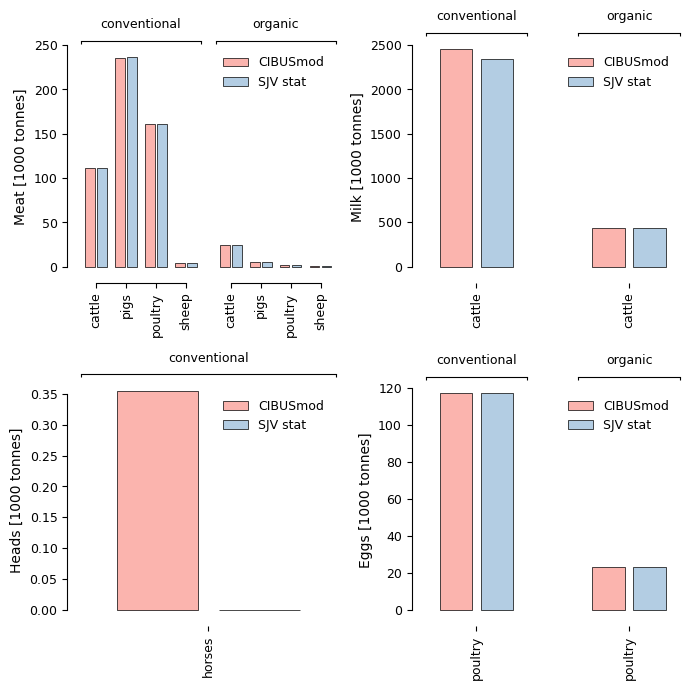

In [320]:
# SJV statistics 2016-2020
# 1000 tonnes
tot_milk = (2862.23+2816.66+2760.23+2704.39+2772.74)/5
org_milk = (369.20+414.23+464.97+464.17+481.20)/5

tot_cattle_meat = (131.25+132.07+136.87+139.67+141.00)/5
org_cattle_meat = (18887+19088+19290+21806+22382+21853)/5/1000

tot_pig_meat = (232.80+240.70+249.79+240.29+246.54)/5
org_pig_meat = (4819+4811+5540+6135+6553)/5/1000

tot_sheep_meat = (5.04+5.26+5.60+5.09+4.86)/5
org_sheep_meat = (1138+1109+1187+1063+993)/5/1000

tot_poultry_meat = (158.03+158.78+156.75+165.22+172.28)/5 # Summa fjäderfä, exkl kasserade
tot_poultry_meat2 = (148.49+148.54+146.28+155.18+162.06)/5 # Slaktkyckling, exkl kasserade
org_poultry_meat2 = (1523+1667+1217+1333+1420)/5/1000 # Slaktkyckling
org_poultry_meat = org_poultry_meat2 * tot_poultry_meat/tot_poultry_meat2

tot_eggs = (120.71*1.135 + 118.19*1.14 + 122.79*1.13 + 130.30*1.13 + 129.74*1.13)/5 
org_eggs = (21.35*1.135 + 20.38*1.14 + 20.54*1.13 + 20.46*1.13 + 20.45*1.13)/5

stat = pd.Series(
    {
        ('conventional','cattle','meat')    : tot_cattle_meat-org_cattle_meat,
        ('organic','cattle','meat')         : org_cattle_meat,
        ('conventional','cattle','milk')    : tot_milk-org_milk,
        ('organic','cattle','milk')         : org_milk,
        ('conventional','pigs','meat')      : tot_pig_meat-org_pig_meat,
        ('organic','pigs','meat')           : org_pig_meat,
        ('conventional','sheep','meat')     : tot_sheep_meat-org_sheep_meat,
        ('organic','sheep','meat')          : org_sheep_meat,
        ('conventional','poultry','meat')   : tot_poultry_meat-org_poultry_meat,
        ('organic','poultry','meat')        : org_poultry_meat,
        ('conventional','poultry','eggs')   : tot_eggs-org_eggs,
        ('organic','poultry','eggs')        : org_eggs
    },
).sort_index().rename_axis(['prod_system','species','animal_prod'])

plot_data = pd.concat([
    session.get_attr('D','animal_prod_demand',['prod_system','species','animal_prod']).loc[(scn,year)].rename('CIBUSmod')/1000000,
    stat.rename('SJV stat')
], axis=1)

aps = plot_data.index.get_level_values('animal_prod').unique()
fig, axs = fig, axs = plt.subplots(2,2, figsize=(7,7))

i=0
for ap in aps:
    ax = axs.flatten()[i]
    cm.plot.bar(
        plot_data.xs(ap,level='animal_prod'),
        ax = ax,
        ylabel=f'{ap.capitalize()} [1000 tonnes]',
        stacked = False,
        group_levels='prod_system',
        **bar_style
    )
    i+=1
    
plt.tight_layout()
plt.show()

### Crop production and use compared to statistics

#### Cereals

In [321]:
data = (
    session.get_attr('c','production')
    .loc[(scn,year)]
    .groupby('crop').sum()
    .loc[['Wheat, winter', 'Wheat, spring','Barley, winter', 'Barley, spring','Oats','Rye']]
    .rename('CIBUSmod')
)/1000000

plot_data = pd.concat([
    data,
    pd.Series([2631,259,112,1353,658,149], index=data.index, name='SCB') # SCB stat database. Total harvest. Average 2016-2020
], axis=1)


cm.plot.bar(
    plot_data,
    stacked = False,
    ax = ax,
    **bar_style
)
plt.show()

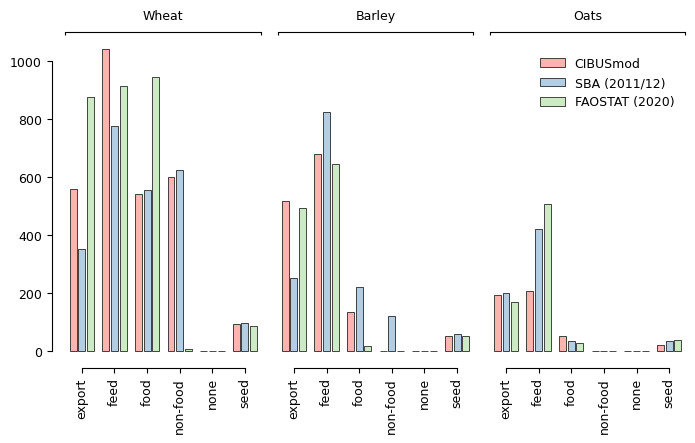

,CIBUSmod,SBA (2011/12),FAOSTAT (2020)
crop,,,
Barley,1 382,1 474,1 204
Oats,471,687,738
Wheat,2 835,2 399,2 827


In [322]:
data = (
    session.get_attr('c','production_per_use')
    .loc[(scn,year)]
    .unstack('demand')
    .groupby('crop')
    .sum()
)/1000000
data.columns = (
    data.columns
    .str.replace('feed.*','feed', regex=True)
)
data = data.T.groupby('demand').sum().T

# Wheat
SBA_1112 = pd.Series([350,775,555,624,0,95], index=data.columns, name='SBA (2011/12)')
FAOSTAT2020 = pd.Series([1423-545,915,944,6,0,84], index=data.columns, name='FAOSTAT (2020)')

wheat = pd.concat([
    data.loc[['Wheat, winter', 'Wheat, spring'],:].sum().rename('CIBUSmod'),
    SBA_1112,
    FAOSTAT2020
], axis=1)
wheat = pd.concat({'Wheat': wheat}, names=['crop'])
# plot_data.plot(**bar_style, title='Wheat')
# plt.show()
# print(plot_data.sum())

# Barley
SBA_1112 = pd.Series([250,825,220,120,0,59], index=data.columns, name='SBA (2011/12)')
FAOSTAT2020 = pd.Series([587-95,644,17,0,0,51], index=data.columns, name='FAOSTAT (2020)')

barley = pd.concat([
    data.loc[['Barley, winter', 'Barley, spring'],:].sum().rename('CIBUSmod'),
    SBA_1112,
    FAOSTAT2020
], axis=1)
barley = pd.concat({'Barley': barley}, names=['crop'])
# plot_data.plot(**bar_style, title='Barley')
# plt.show()
# print(plot_data.sum())

# Oats
SBA_1112 = pd.Series([200,420,35,0,0,32], index=data.columns, name='SBA (2011/12)')
FAOSTAT2020 = pd.Series([188-20,507,26,0,0,37], index=data.columns, name='FAOSTAT (2020)')

oats = pd.concat([
    data.loc[['Oats'],:].sum().rename('CIBUSmod'),
    SBA_1112,
    FAOSTAT2020
], axis=1)
oats = pd.concat({'Oats': oats}, names=['crop'])
# plot_data.plot(**bar_style, title='Oats')
# plt.show()
# print(plot_data.sum())

plot_data = pd.concat([wheat, barley, oats])

fig, ax = plt.subplots(figsize=(8,4))
cm.plot.bar(
    plot_data,
    group_levels='crop',
    stacked=False,
    **bar_style
)
plt.show()

(
    plot_data
    .groupby('crop').sum()
    .style
    .format(precision=0, thousands=" ")
)

### Manure excretion

#### Volatile solids

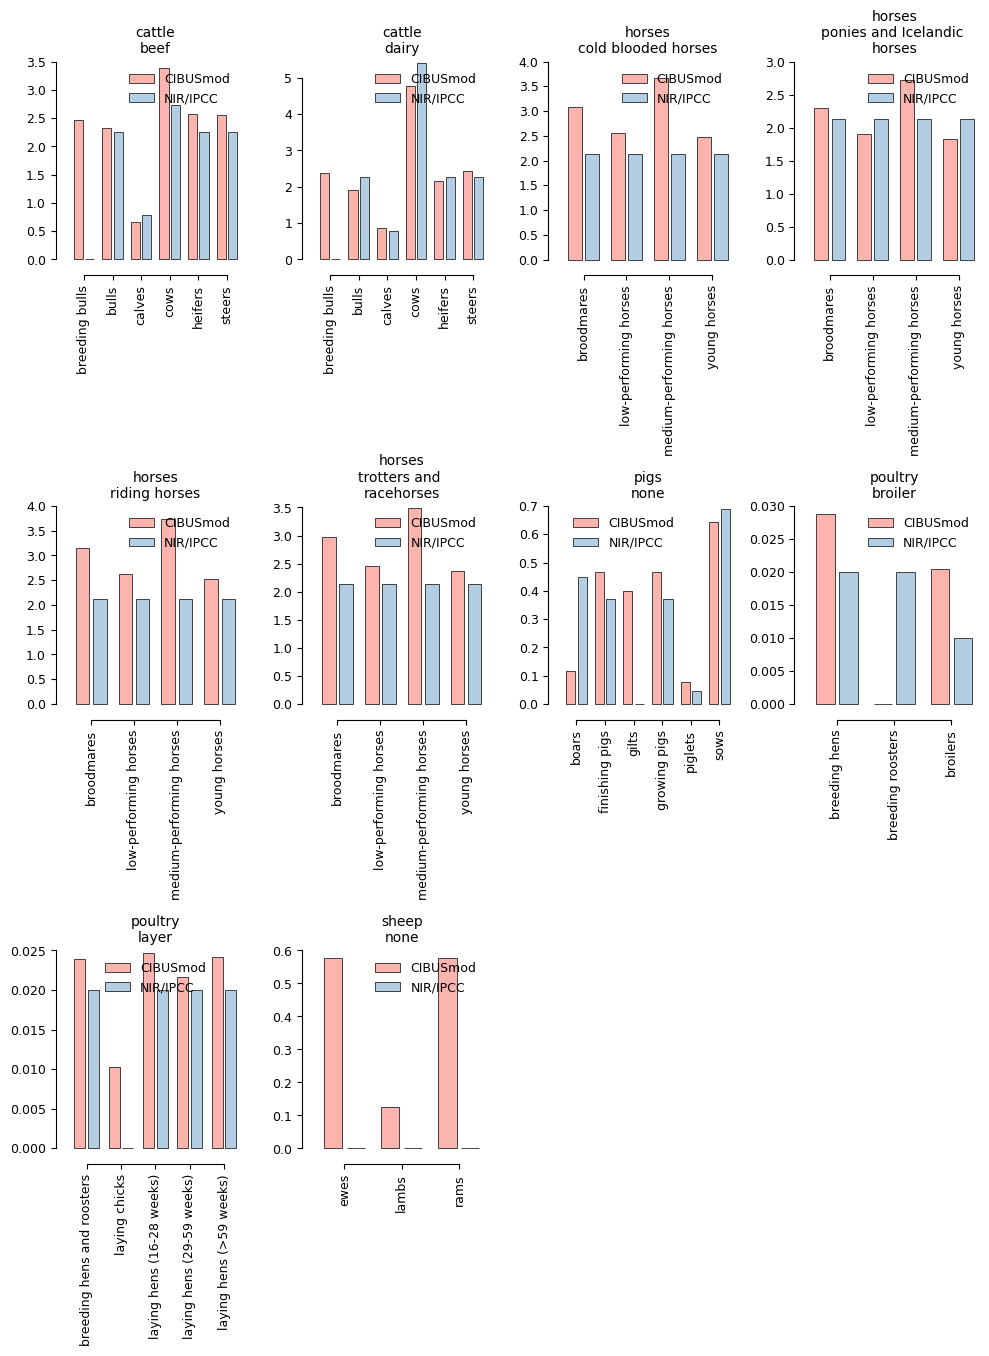

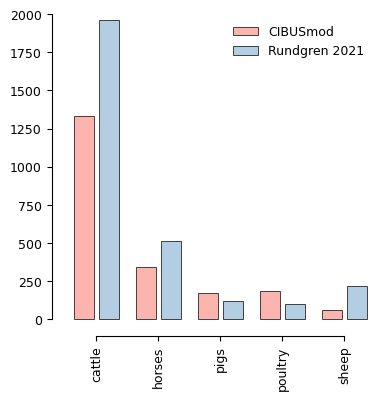

In [323]:
VS_per_head = (
    session.get_attr('A','manure.VS_excr',['species','breed','animal']) / 
    session.get_attr('A','heads',['species','breed','animal']) /
    365.25
).loc[(scn,year)].rename('CIBUSmod')

NIR_IPCC = pd.Series({
    ('cattle','dairy','cows'):5.39,
    ('cattle','dairy','calves'):0.79,
    ('cattle','dairy','heifers'):2.26,
    ('cattle','dairy','steers'):2.26,
    ('cattle','dairy','bulls'):2.26,
    ('cattle','beef','cows'):2.74, # Avg. grazing / stable
    ('cattle','beef','calves'):0.79,
    ('cattle','beef','heifers'):2.26,
    ('cattle','beef','steers'):2.26,
    ('cattle','beef','bulls'):2.26,
    ('horses','cold blooded horses','broodmares') : 2.13,
    ('horses','cold blooded horses','low-performing horses') : 2.13,
    ('horses','cold blooded horses','medium-performing horses') : 2.13,
    ('horses','cold blooded horses','young horses') : 2.13,
    ('horses','ponies and Icelandic horses','broodmares') : 2.13,
    ('horses','ponies and Icelandic horses','low-performing horses') : 2.13,
    ('horses','ponies and Icelandic horses','medium-performing horses') : 2.13,
    ('horses','ponies and Icelandic horses','young horses') : 2.13,
    ('horses','riding horses','broodmares') : 2.13,
    ('horses','riding horses','low-performing horses') : 2.13,
    ('horses','riding horses','medium-performing horses') : 2.13,
    ('horses','riding horses','young horses') : 2.13,
    ('horses','trotters and racehorses','broodmares') : 2.13,
    ('horses','trotters and racehorses','low-performing horses') : 2.13,
    ('horses','trotters and racehorses','medium-performing horses') : 2.13,
    ('horses','trotters and racehorses','young horses') : 2.13,
    ('pigs','none','boars') : 0.45,
    ('pigs','none','finishing pigs') : 0.37,
    ('pigs','none','gilts') : np.nan,
    ('pigs','none','growing pigs') : 0.37,
    ('pigs','none','piglets') : 0.044,
    ('pigs','none','sows') : 0.69,
    ('poultry','broiler','breeding hens') : 0.02,
    ('poultry','broiler','breeding roosters') : 0.02,
    ('poultry','broiler','broilers') : 0.01,
    ('poultry','layer','breeding hens and roosters') : 0.02,
    ('poultry','layer','laying chicks') : np.nan,
    ('poultry','layer','laying hens (16-28 weeks)') : 0.02,
    ('poultry','layer','laying hens (29-59 weeks)') : 0.02,
    ('poultry','layer','laying hens (>59 weeks)') : 0.02,
}).rename('NIR/IPCC')
NIR_IPCC.index.names = VS_per_head.index.names

plot_data = pd.concat([
    VS_per_head,
    NIR_IPCC
], axis=1)

fig,axs = plot.subplots(
    plot_data,
    ['species','breed'],
    plot_fn=cm.plot.bar,
    **bar_style,
    stacked=False,
    title_fontsize=10,
    size=(2.5,4.5)
)
plt.tight_layout()
plt.show()

# Compared to Rundgren 2021
plot_data = pd.concat([
    session.get_attr('A','manure.VS_excr','species').loc[(scn,year)].rename('CIBUSmod')/1000000,
    pd.Series(
        [1960,510,217,119,60+39],
        index=pd.Index(['cattle','horses','sheep','pigs','poultry'], name='species'),
        name='Rundgren 2021'
    )
], axis=1)

fig, ax = plt.subplots(figsize=(4,4))
cm.plot.bar(
    plot_data,
    stacked = False,
    ax = ax,
    **bar_style
)
plt.show()

#### Nitrogen

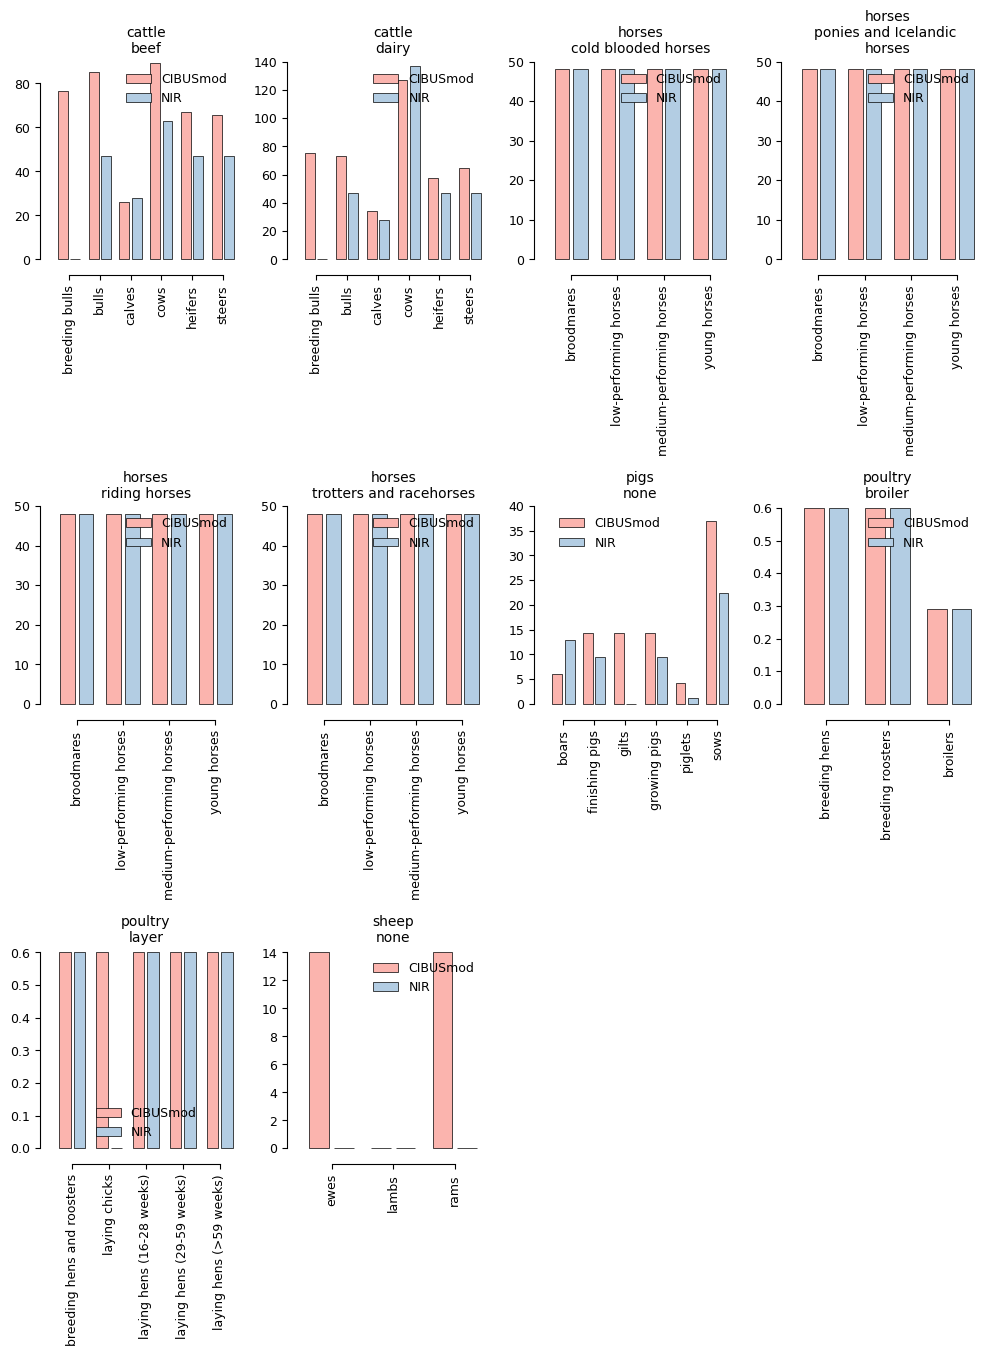

In [324]:
N_per_head = (
    session.get_attr('A','manure.N_excr',['species','breed','animal']) / 
    session.get_attr('A','heads',['species','breed','animal'])
).loc[(scn,year)].rename('CIBUSmod')

NIR = pd.Series({
    ('cattle','dairy','cows'):137,
    ('cattle','dairy','calves'):28,
    ('cattle','dairy','heifers'):47,
    ('cattle','dairy','steers'):47,
    ('cattle','dairy','bulls'):47,
    ('cattle','beef','cows'):63,
    ('cattle','beef','calves'):28,
    ('cattle','beef','heifers'):47,
    ('cattle','beef','steers'):47,
    ('cattle','beef','bulls'):47,
    ('horses','cold blooded horses','broodmares') : 48,
    ('horses','cold blooded horses','low-performing horses') : 48,
    ('horses','cold blooded horses','medium-performing horses') : 48,
    ('horses','cold blooded horses','young horses') : 48,
    ('horses','ponies and Icelandic horses','broodmares') : 48,
    ('horses','ponies and Icelandic horses','low-performing horses') : 48,
    ('horses','ponies and Icelandic horses','medium-performing horses') : 48,
    ('horses','ponies and Icelandic horses','young horses') : 48,
    ('horses','riding horses','broodmares') : 48,
    ('horses','riding horses','low-performing horses') : 48,
    ('horses','riding horses','medium-performing horses') : 48,
    ('horses','riding horses','young horses') : 48,
    ('horses','trotters and racehorses','broodmares') : 48,
    ('horses','trotters and racehorses','low-performing horses') : 48,
    ('horses','trotters and racehorses','medium-performing horses') : 48,
    ('horses','trotters and racehorses','young horses') : 48,
    ('pigs','none','boars') : 13,
    ('pigs','none','finishing pigs') : 9.5,
    ('pigs','none','gilts') : np.nan,
    ('pigs','none','growing pigs') : 9.5,
    ('pigs','none','piglets') : 1.2,
    ('pigs','none','sows') : 22.5,
    ('poultry','broiler','breeding hens') : 0.6,
    ('poultry','broiler','breeding roosters') : 0.6,
    ('poultry','broiler','broilers') : 0.29,
    ('poultry','layer','breeding hens and roosters') : 0.6,
    ('poultry','layer','laying chicks') : np.nan,
    ('poultry','layer','laying hens (16-28 weeks)') : 0.6,
    ('poultry','layer','laying hens (29-59 weeks)') : 0.6,
    ('poultry','layer','laying hens (>59 weeks)') : 0.6,
}).rename('NIR')
NIR.index.names = N_per_head.index.names

plot_data = pd.concat([
    N_per_head,
    NIR
], axis=1)

fig,axs = plot.subplots(
    plot_data,
    ['species','breed'],
    plot_fn=cm.plot.bar,
    **bar_style,
    stacked=False,
    title_fontsize=10,
    size=(2.5,4.5)
)
plt.tight_layout()
plt.show()

### GHG emissions compared to NIR

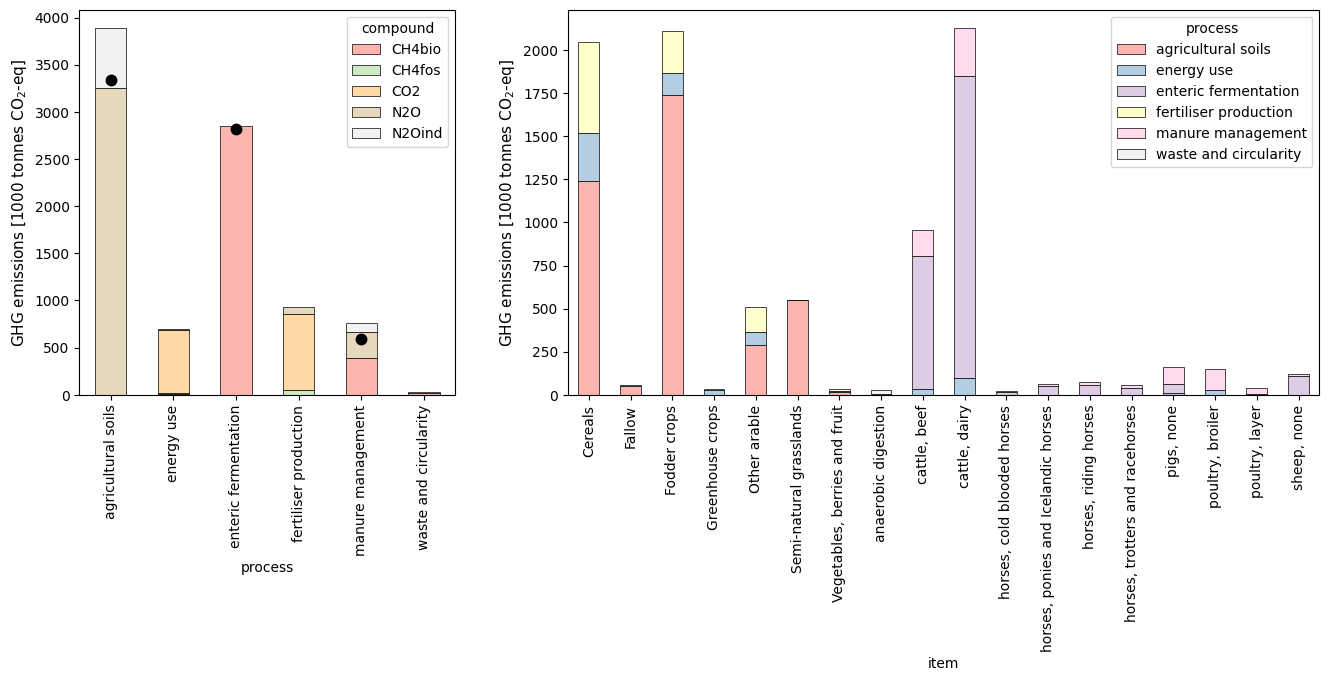

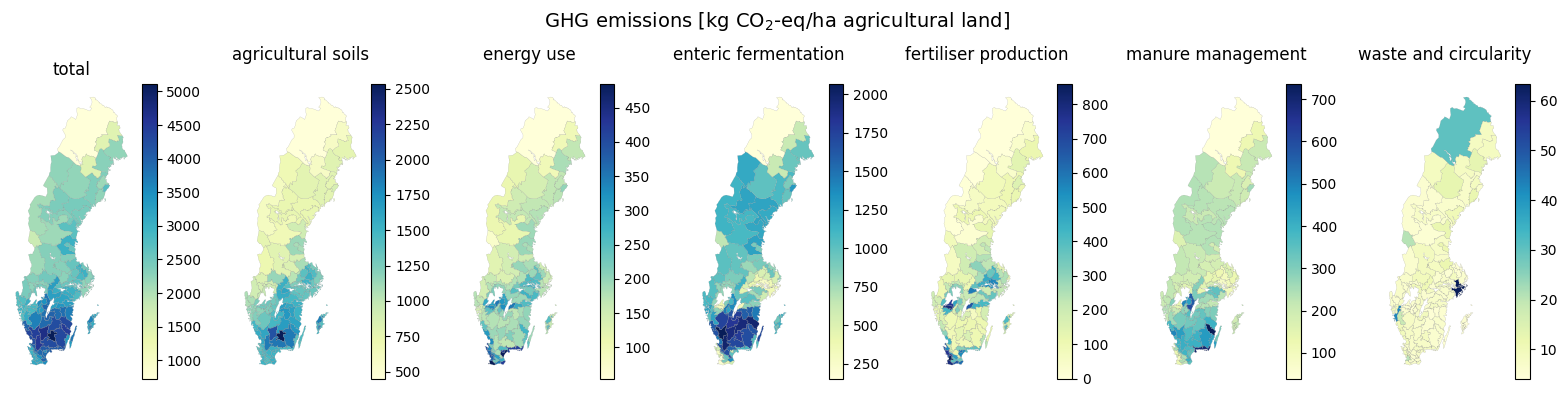

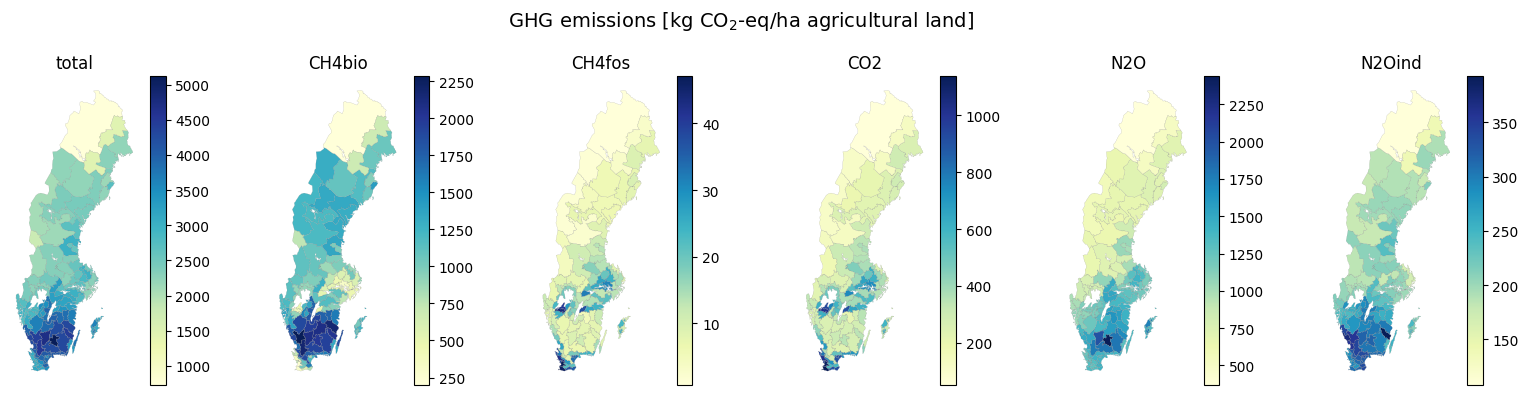

In [325]:
# Bar plot [1000 tonnes CO2eq] ----->

GHG_data = cm.get_GHG(session, scn='base year')

fig, axs = plt.subplots(1,2, figsize=(16,5), gridspec_kw={'width_ratios': [1, 2]})
plot_data = (
    GHG_data.loc[(scn,year)]
    .groupby(['process','compound'])
    .sum()
    .unstack()
    /1000000
)
# Avg. 2016-2020 https://www.naturvardsverket.se/data-och-statistik/klimat/vaxthusgaser-utslapp-fran-jordbruk/
plot_data_NIR = pd.Series(
    [3341.2,np.nan,2820.8,np.nan,590.8,np.nan]
)

ax=axs[0]
plot_data_NIR.plot(kind='line', ax=ax, linestyle='', marker='.', markersize=15, color='black')
plot_data.plot(**pd_bar_style, stacked=True, ax=ax)
ax.set_ylabel(r'GHG emissions [1000 tonnes CO$_2$-eq]', size=11)

plot_data = (
    GHG_data.loc[(scn,year)]
    .groupby(['item','process'])
    .sum()
    .unstack()
    /1000000
)
ax = axs[1]
plot_data.plot(**pd_bar_style, stacked=True, ax=ax)
ax.set_ylabel(r'GHG emissions [1000 tonnes CO$_2$-eq]', size=11)

plt.show()

# Maps [kg CO2eq/ha] ----->
area = (
    session.get_attr('C','area',{'crop':'land_use','region':None})
    .loc[(scn,year)].drop('greenhouse')
    .groupby('region').sum()
)

# per process
plot_data = (
    GHG_data.loc[(scn,year)]
    .groupby(['region','process'])
    .sum()
    .unstack()
    .mul(1/area, axis=0)
)
n_proc = len(plot_data.columns)

fig, axs = plt.subplots(1,n_proc+1, figsize=(16,4))
ax = axs[0]
plot.map_from_series(plot_data.sum(axis=1), **map_style, ax=ax)
ax.set_title('total')
ax.axis('off')
i = 1
for proc in plot_data.columns:
    ax = axs[i]
    plot.map_from_series(plot_data[proc], **map_style, ax=ax)
    ax.set_title(proc)
    ax.axis('off')
    i += 1
plt.suptitle(r'GHG emissions [kg CO$_{2}$-eq/ha agricultural land]', size=14)
plt.tight_layout()
plt.show()

# per GHG
plot_data = (
    GHG_data.loc[(scn,year)]
    .groupby(['region','compound'])
    .sum()
    .unstack()
    .mul(1/area, axis=0)
)
n_ghg = len(plot_data.columns)

fig, axs = plt.subplots(1,n_ghg+1, figsize=(16,4))
ax = axs[0]
plot.map_from_series(plot_data.sum(axis=1), **map_style, ax=ax)
ax.set_title('total')
ax.axis('off')
i = 1
for cp in plot_data.columns:
    ax = axs[i]
    plot.map_from_series(plot_data[cp], **map_style, ax=ax)
    ax.set_title(cp)
    ax.axis('off')
    i += 1
plt.suptitle(r'GHG emissions [kg CO$_{2}$-eq/ha agricultural land]', size=14)
plt.tight_layout()
plt.show()

### Nitrogen in manure and fertiliser

In [24]:
# Statisticts of nitrogen (total N) application on cropland for the years 2018/2019 and 2021/2022
# per total area of cropland in the region (i.e. includinga areas receiving no fertiliser) 
# [kg N/ha]

stat_N_per_ha = pd.DataFrame(
    {
        'manure' : [
            11.8,
            11.0,
            21.1,
            34.3,
            75.1,
            59.7,
            59.9,
            37.1,
            43.0,
            24.3,
            47.9,
            34.8,
            32.2,
            19.9,
            11.1,
            32.6,
            43.8,
            37.2,
            54.4,
            44.4,
            37.4
        ],
        'mineral' : [
            62.3,
            80.0,
            74.0,
            80.6,
            39.6,
            41.7,
            72.2,
            66.4,
            65.0,
            109.2,
            84.8,
            73.5,
            42.7,
            76.7,
            73.4,
            38.0,
            30.0,
            20.5,
            np.nan,
            31.7,
            32.0,
        ]
    },
    index = [
        '01 Stockholms län',
        '03 Uppsala län',
        '04 Södermanlands län',
        '05 Östergötlands län',
        '06 Jönköpings län',
        '07 Kronobergs län',
        '08 Kalmar län',
        '09 Gotlands län',
        '10 Blekinge län',
        '12 Skåne län',
        '13 Hallands län',
        '14 Västra Götalands län',
        '17 Värmlands län',
        '18 Örebro län',
        '19 Västmanlands län',
        '20 Dalarnas län',
        '21 Gävleborgs län',
        '22 Västernorrlands län',
        '23 Jämtlands län',
        '24 Västerbottens län',
        '25 Norrbottens län'
    ]
)
stat_N_per_ha['total'] = stat_N_per_ha.sum(axis=1)

# Total for sweden (SCB, Gödselemedl i jordbruket)
# Avg. 2015/2016, 2018/2019 and 2021/2022
stat_total = pd.Series({ # [1000 tonnes N/P/K]
    ('N','mineral fertiliser') : 170,
    ('N','manure')  : 78,
    ('N','organic fertiliser') : (3590+4370)/2/1000/0.4, # Tablå 3, avg 2018/19 and 2021/22, assuming 40% of N plant available
    ('P','mineral fertiliser') : 13,
    ('P','manure')  : 17,
    ('P','organic fertiliser') : (820+910)/2/1000, # Tablå 3, avg 2018/19 and 2021/22
    ('K','mineral fertiliser') : 29,
    ('K','manure')  : 92,
    ('K','organic fertiliser') : (2960+3110)/2/1000 # Tablå 3, avg 2018/19 and 2021/22
})
stat_crop_tot = pd.Series({ # [1000 tonnes N/P/K]
    ('N', 'Not included') : np.nan,
    ('N', 'Ley for grazing') : 2.7,
    ('N', 'Other') : 37,
    ('N', 'Ley for fodder') : 79,
    ('N', 'Cereals') : 130,
    ('P', 'Not included') : np.nan,
    ('P', 'Ley for grazing') : 0.3,
    ('P', 'Other') : 6.1,
    ('P', 'Ley for fodder') : 10,
    ('P', 'Cereals') : 14,
    ('K', 'Not included') : np.nan,
    ('K', 'Ley for grazing') : 1.7,
    ('K', 'Other') : 22,
    ('K', 'Ley for fodder') : 60,
    ('K', 'Cereals') : 37,
})
stat_crop_tot_mineral = pd.Series({ # [1000 tonnes N/P/K]
    ('N', 'Not included') : np.nan,
    ('N', 'Ley for grazing') : 1.6,
    ('N', 'Other') : 25,
    ('N', 'Ley for fodder') : 38,
    ('N', 'Cereals') : 106,
    ('P', 'Not included') : np.nan,
    ('P', 'Ley for grazing') : 0.1,
    ('P', 'Other') : 3.4,
    ('P', 'Ley for fodder') : 1.4,
    ('P', 'Cereals') : 8.2,
    ('K', 'Not included') : np.nan,
    ('K', 'Ley for grazing') : 0.3,
    ('K', 'Other') : 10,
    ('K', 'Ley for fodder') : 5,
    ('K', 'Cereals') : 13,
})
stat_crop_per_ha = pd.Series({ # [kg N/P/K per ha]
    ('N', 'Not included') : np.nan, # Not incl
    ('N', 'Ley for grazing') : 24,
    ('N', 'Other') : 116,
    ('N', 'Ley for fodder') : 111,
    ('N', 'Cereals') : 133,
    ('P', 'Not included') : np.nan,
    ('P', 'Ley for grazing') : 2.9,
    ('P', 'Other') : 20,
    ('P', 'Ley for fodder') : 15,
    ('P', 'Cereals') : 16,
    ('K', 'Not included') : np.nan,
    ('K', 'Ley for grazing') : 16,
    ('K', 'Other') : 71,
    ('K', 'Ley for fodder') : 88,
    ('K', 'Cereals') : 44,
})

---------
base year
---------


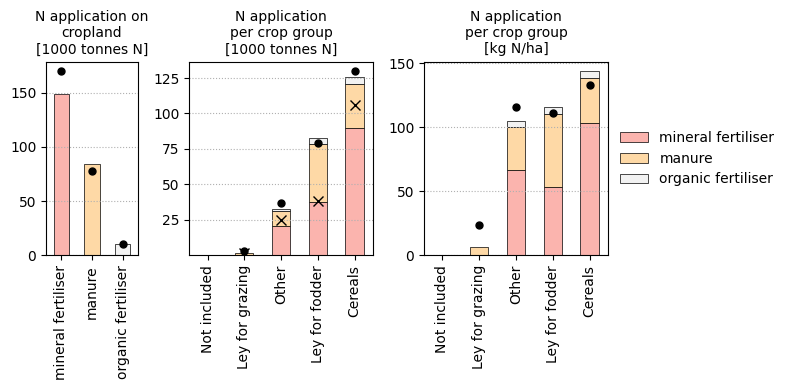

,CIBUSmod,SCB (2016-2020),Difference
mineral fertiliser,149,170,-13
manure,84,78,8
organic fertiliser,10,10,4


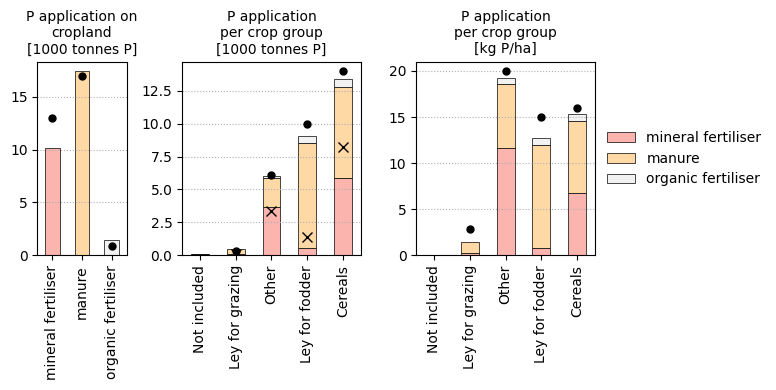

,CIBUSmod,SCB (2016-2020),Difference
mineral fertiliser,10,13,-22
manure,17,17,3
organic fertiliser,1,1,62


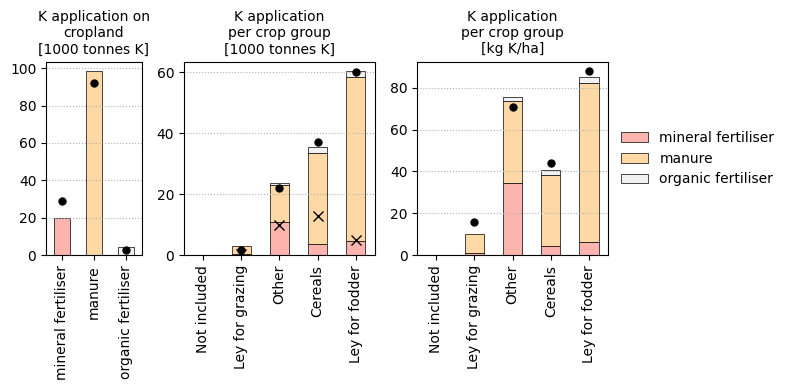

,CIBUSmod,SCB (2016-2020),Difference
mineral fertiliser,20,29,-32
manure,98,92,7
organic fertiliser,5,3,52


-------------------------
base year (x0 crop areas)
-------------------------


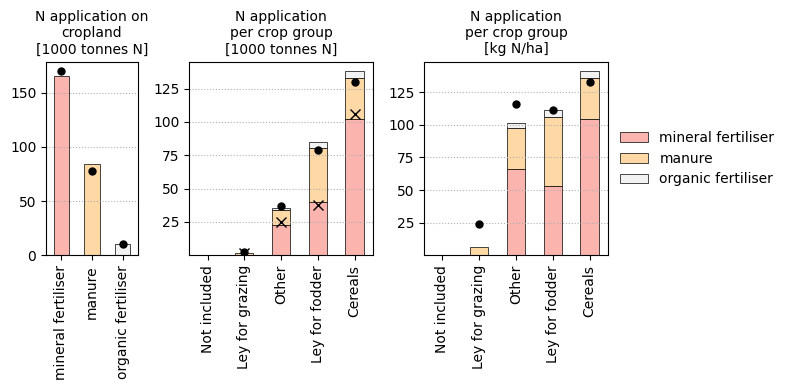

,CIBUSmod,SCB (2016-2020),Difference
mineral fertiliser,165,170,-3
manure,84,78,8
organic fertiliser,10,10,4


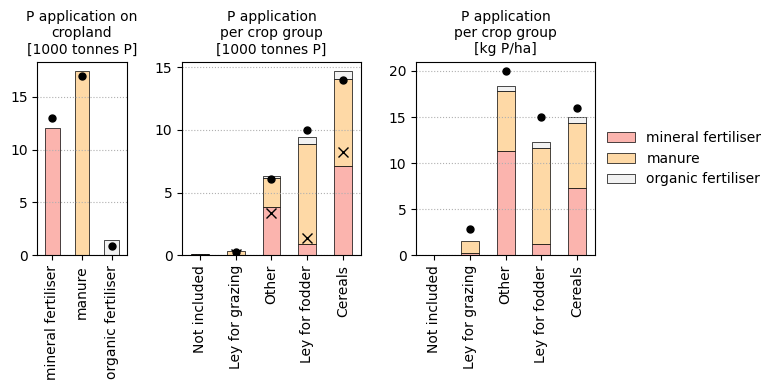

,CIBUSmod,SCB (2016-2020),Difference
mineral fertiliser,12,13,-8
manure,17,17,3
organic fertiliser,1,1,62


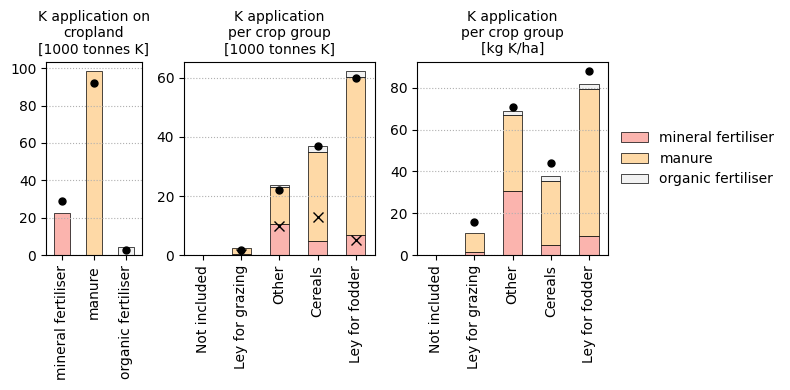

,CIBUSmod,SCB (2016-2020),Difference
mineral fertiliser,23,29,-22
manure,98,92,7
organic fertiliser,5,3,52


In [32]:
for scn in ['base year', 'base year (x0 crop areas)']:
    print('-'*len(scn), scn, '-'*len(scn), sep='\n')
    for element in ['N','P','K']:
        area = (
            session.get_attr(
                'C',
                'area',
                {'crop':'crop_group_fertstat'}
            )
            .loc[(scn,year)]
        )
        mineral_fert = (
            session.get_attr(
                'C',f'fertiliser.mineral_{element}',
                {'crop':'crop_group_fertstat'}
            )
            .loc[(scn,year)]
            .rename('mineral fertiliser')
        )
        manure = (
            session.get_attr(
                'C',
                f'fertiliser.manure_{element}',
                {'crop':'crop_group_fertstat', 'MMS':None}
            )
            .loc[(scn,year)]
            .drop('grazing', level='MMS')
            .groupby('crop_group_fertstat')
            .sum()
            .rename('manure')
        )
        organic_fert = (
            session.get_attr(
                'C',f'fertiliser.organic_{element}',
                {'crop':'crop_group_fertstat'}
            )
            .loc[(scn,year)]
            .rename('organic fertiliser')
        )
        
        plot_data = pd.concat([mineral_fert, manure, organic_fert], axis=1)/1000000
        plot_data = plot_data.reindex(set(plot_data.index.to_list()+['Not included']), fill_value=0)
        plot_data_tot = plot_data.sum().rename('mineral fertiliser').to_frame()
        plot_data_tot['manure'] = plot_data_tot['mineral fertiliser'] * [0 if i in ['mineral fertiliser','organic fertiliser'] else 1 for i in plot_data_tot.index]
        plot_data_tot['organic fertiliser'] = plot_data_tot['mineral fertiliser'] * [1 if i == 'organic fertiliser' else 0 for i in plot_data_tot.index]
        plot_data_tot['mineral fertiliser'] = plot_data_tot['mineral fertiliser'] * [1 if i == 'mineral fertiliser' else 0 for i in plot_data_tot.index]
        
        fig, axs = plt.subplots(1,3, figsize=(8,4), gridspec_kw={'width_ratios': [1, 2, 2]})
        # Total manure and mineral fertiliser [tonnes]
        ax = axs[0]
        plot_data_tot.T.plot(**pd_bar_style, stacked=True, ax = ax, legend=False)
        stat_total.loc[element].plot(kind='line', ax=ax, linestyle='', marker='.', markersize=10, color='black')
        ax.set_xticks(ax.get_xticks(), ax.get_xticklabels(), rotation=90, ha='center')
        ax.grid('on', linestyle=':', which='both', axis='y')
        ax.set_xlabel('')
        ax.set_title(f'{element} application on\ncropland\n[1000 tonnes {element}]', size=10)
        
        # Manure and mineral fertiliser per crop group
        ax = axs[1]
        s = plot_data.sum(axis=1).sort_values().index
        plot_data.loc[s].plot(**pd_bar_style, stacked=True, ax=ax, legend=False)
        stat_crop_tot.loc[element].loc[s].plot(kind='line', ax=ax, linestyle='', marker='.', markersize=10, color='black')
        stat_crop_tot_mineral.loc[element].loc[s].plot(kind='line', ax=ax, linestyle='', marker='x', markersize=7, color='black')
        ax.set_xticks(ax.get_xticks(), ax.get_xticklabels(), rotation=90, ha='center')
        ax.grid('on', linestyle=':', which='both', axis='y')
        ax.set_xlabel('')
        ax.set_title(f'{element} application\nper crop group\n[1000 tonnes {element}]', size=10)
        
        # Manure and mineral fertiliser per crop group per area
        ax = axs[2]
        (plot_data.div(area, axis=0)*1000000).loc[s].plot(**pd_bar_style, stacked=True, ax=ax)
        stat_crop_per_ha.loc[element].loc[s].plot(kind='line', ax=ax, linestyle='', marker='.', markersize=10, color='black')
        ax.set_xticks(ax.get_xticks(), ax.get_xticklabels(), rotation=90, ha='center')
        ax.grid('on', linestyle=':', which='both', axis='y')
        ax.set_xlabel('')
        ax.set_title(f'{element} application\nper crop group\n[kg {element}/ha]', size=10)
    
        plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=False)
        plt.tight_layout()
        plt.show()

        table_data = pd.concat([plot_data_tot.sum().rename('CIBUSmod'), stat_total.loc[element].rename('SCB (2016-2020)')], axis=1)
        table_data['Difference'] = (table_data['CIBUSmod'] - table_data['SCB (2016-2020)']) / table_data['SCB (2016-2020)'] * 100
        display(table_data.style.format(precision=0))
        
scn = 'base year'

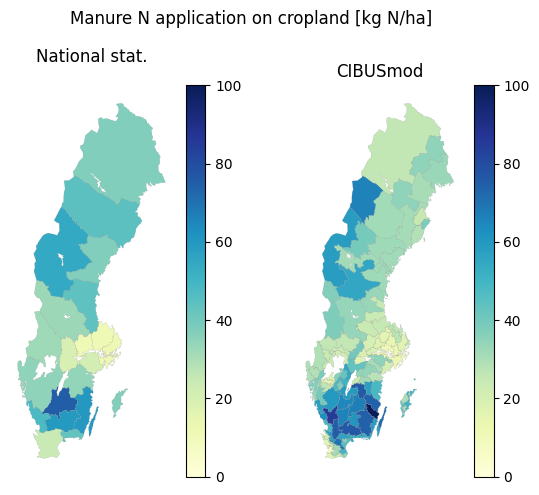

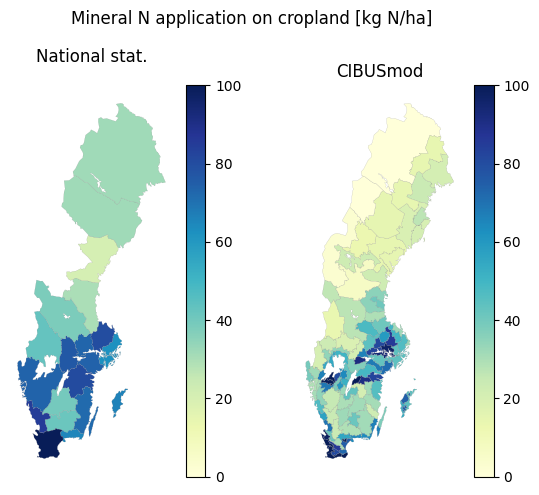

In [328]:
area = (
    session.get_attr('C','area',{'crop':'land_use','region':None})
    .loc[(scn,year),'cropland']
)

# Manure per ha
fig, axs = plt.subplots(1,2, figsize=(6,5))
ax = axs[0]
ax.set_title('National stat.')
ax.axis('off')
plot.map_from_series(stat_N_per_ha['manure'], reg='län', **map_style, ax=ax, vmin=0, vmax=100)

ax = axs[1]
ax.set_title('CIBUSmod')
ax.axis('off')
plot_data = (
    session
    .get_attr('C','fertiliser.manure_N',{'crop':'land_use', 'MMS':None, 'region':None})
    .loc[(scn,year)]
    .drop('grazing', level='MMS')
    .groupby('region').sum()
    / area
)
plot.map_from_series(plot_data, **map_style, ax=ax, vmin=0, vmax=100)
plt.suptitle('Manure N application on cropland [kg N/ha]')
plt.tight_layout()
plt.show()

# Mineral per ha
fig, axs = plt.subplots(1,2, figsize=(6,5))
ax = axs[0]
ax.set_title('National stat.')
ax.axis('off')
plot.map_from_series(stat_N_per_ha['mineral'], reg='län', **map_style, ax=ax, vmin=0, vmax=100)

ax = axs[1]
ax.set_title('CIBUSmod')
ax.axis('off')
plot_data = (
    session
    .get_attr('C','fertiliser.mineral_N',{'crop':'land_use', 'region':None})
    .loc[(scn,year)]
    .groupby('region').sum()
    / area
)
plot.map_from_series(plot_data, **map_style, ax=ax, vmin=0, vmax=100)
plt.suptitle('Mineral N application on cropland [kg N/ha]')
plt.tight_layout()
plt.show()

In [329]:
excr = session.get_attr('a','manure.N_excr','none').loc[[(scn,year)]].rename('excretion')
excr.index = pd.Index(['N'], name='compound')
to_treatment = session.get_attr('a','manure.N_to_treatment','none').loc[[(scn,year)]]
to_treatment.index = pd.Index(['N'], name='compound')
to_spread = (
    session.get_attr('a','manure.N_to_spread','none').loc[[(scn,year)]] +
    session.get_attr('w','organic_fertiliser_N',['feedstock_type']).loc[[(scn,year)], 'manure']
).rename('to spread')
to_spread.index = pd.Index(['N'], name='compound')
loss = (
    session.get_attr('a','manure.N_loss',['compound']).loc[(scn,year)].add(
        session.get_attr('w','losses_N',['feedstock_type', 'compound']).loc[(scn,year), 'manure'],
        fill_value=0
    )
).rename('losses')
appl_loss = pd.concat([
    session.get_attr('c','fertiliser.manure_N_soil_loss','compound').loc[(scn,year)],
    session.get_attr('c','fertiliser.manure_N_application_loss','compound').loc[(scn,year)]
]).rename('application/soil loss')

cibus = pd.concat([excr, loss, to_spread, appl_loss], axis=1).fillna(0).rename_axis('stage', axis=1)/1_000_000
cibus = pd.concat({'CIBUSmod': cibus}, names=['source'], axis=1)

Einarsson_data = {
    'index': ['N', 'N2', 'N2O-N', 'NH3-N', 'NOx-N'],
    'columns': [('Einarsson et al (2022)', i) for i in ['excretion', 'losses', 'to spread', 'application/soil loss']],
    'data': [[134.02, 0,         39.82+72.45, 0],
             [0,      3.92,      0,           0],
             [0,      0.51,      0,           0.69+72.45*0.01],
             [0,      7.31+9.88, 0,           3.10+12.69],
             [0,      0.13,      0,           0]],
    'index_names': ['compound'],
    'column_names': ['source', 'stage']
}
Einarsson = pd.DataFrame.from_dict(Einarsson_data, orient='tight')

plot_data = pd.concat([cibus, Einarsson], axis=1)

In [330]:
table_data = plot_data.stack('stage').replace({0:np.nan}).dropna(how='all').reorder_levels([1,0]).sort_index()
table_data['Diferance'] = (table_data['CIBUSmod'] - table_data['Einarsson et al (2022)']) / table_data['Einarsson et al (2022)'] * 100
display(table_data.style.format(precision=2))

In [331]:
# Share of excretion lost
plot_data.sum().groupby('source').apply(lambda x: x.loc[(slice(None),'losses')].sum()/x.loc[(slice(None),'excretion')].sum()*100)

source
CIBUSmod                  17.039521
Einarsson et al (2022)    16.228921
dtype: float64

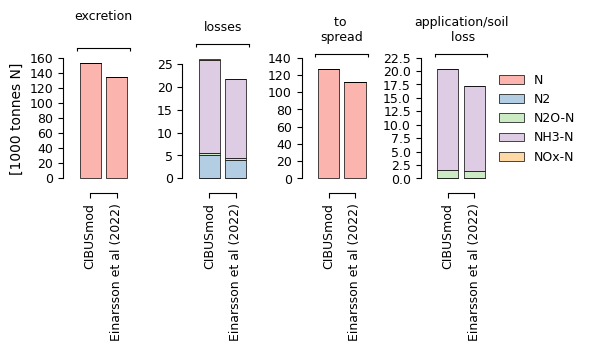

In [332]:
fig, axs = plt.subplots(1,4, figsize=(6,3.5))

for i, s in enumerate(plot_data.columns.unique('stage')):
    ax = axs[i]
    d = plot_data.T.loc[(slice(None),s),:]
    cm.plot.bar(
        d,
        stacked = True,
        group_levels='stage',
        ylabel='[1000 tonnes N]' if i==0 else '',
        ax = ax,
        **bar_style
    )
    if i < len(axs) - 1:
        ax.legend().remove()
    else:
        ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9, frameon=False)

plt.tight_layout()
plt.show()

### Waste treatment

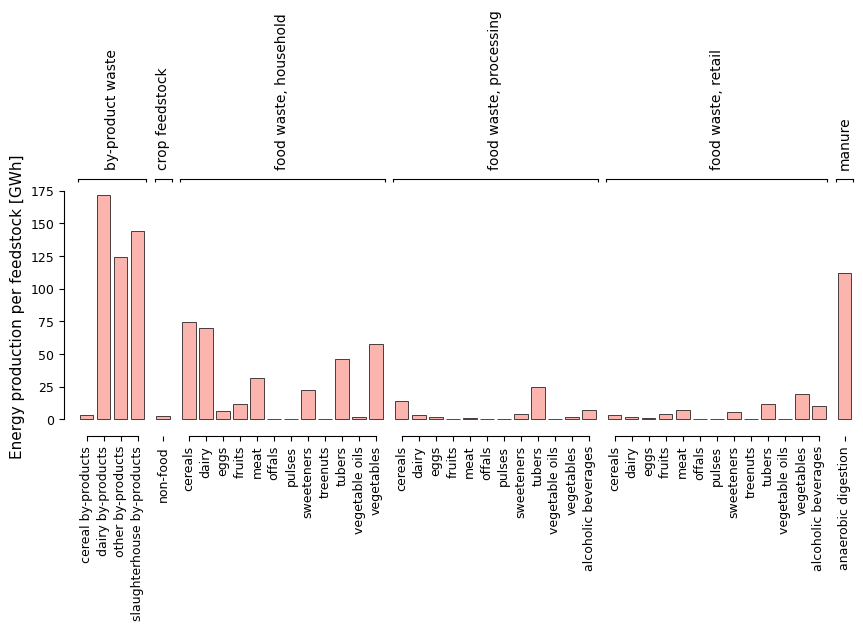

In [333]:
plot_data = (
    session.get_attr('w', 'energy_prod', ['feedstock_type', 'feedstock_group', 'treatment'])
    .loc[(scn,year)]
    .unstack()
)/1000000 # GWh

fig, ax = plt.subplots(figsize=(10,3))
cm.plot.bar(
    plot_data,
    group_levels='feedstock_type',
    ticklabels_fontsize=9,
    grouplabels_vertical=True,
    cmap='Pastel1',
    ylabel='Energy production per feedstock [GWh]'
)
plt.show()

In [334]:


print('2016 (alla anläggningar)')
tot_2016 = 2_018 #GWh
print('food waste:',tot_2016 * 11/100,'GWh')
print('manure:',tot_2016 * 19/100,'GWh')
print('food industry:',tot_2016 * 10/100,'GWh')

print('\n2020 (alla anläggningar)')
tot_2020 = 2_161 #GWh
print('food waste:',tot_2020 * 21/100,'GWh')
print('manure:',tot_2020 * 11/100,'GWh')
print('food industry:',tot_2020 * 7/100,'GWh')

print('\n2022 (samrötning)')
tot_2022 = 1_145 #GWh
print('food waste:',round(tot_2022 * ((426*148)/(426*148+661*26+293*66+186*120+204*100))),'GWh')
print('manure:',round(tot_2022 * ((661*26)/(426*148+661*26+293*66+186*120+204*100))),'GWh')
print('food industry:',round(tot_2022 * ((293*66)/(426*148+661*26+293*66+186*120+204*100))),'GWh')

print('\nCIBUSmod energy production [GWh]')
print(session.get_attr('w','energy_prod').loc[(scn,year)].groupby(['treatment','feedstock_type']).sum()/1000000)

print(
    '',
    '---------------------------',
    'Total N in feedstocks to AD',
    '---------------------------',
    sep='\n'
)
print(
    'Swe IIR 2023 Table 6-11 (avg 2016-2020):',
    round((13_139+12_934+13_880+15_119+15_017)/5),
    't N'
)
print(
    'CIBUSmod:',
    round(session.get_attr('w','feedstock_N').loc[(scn,year)].xs('anaerobic digestion', level='treatment').sum()/1000),
    't N'
)

2016 (alla anläggningar)
food waste: 221.98 GWh
manure: 383.42 GWh
food industry: 201.8 GWh

2020 (alla anläggningar)
food waste: 453.81 GWh
manure: 237.71 GWh
food industry: 151.27 GWh

2022 (samrötning)
food waste: 507 GWh
manure: 138 GWh
food industry: 156 GWh

CIBUSmod energy production [GWh]
treatment            feedstock_type        
anaerobic digestion  by-product waste          442.778347
                     crop feedstock              2.271180
                     food waste, household     324.145806
                     food waste, processing     59.010527
                     food waste, retail         65.052955
                     manure                    111.621335
Name: (base year, 2020), dtype: float64

---------------------------
Total N in feedstocks to AD
---------------------------
Swe IIR 2023 Table 6-11 (avg 2016-2020): 14018 t N
CIBUSmod: 10692 t N


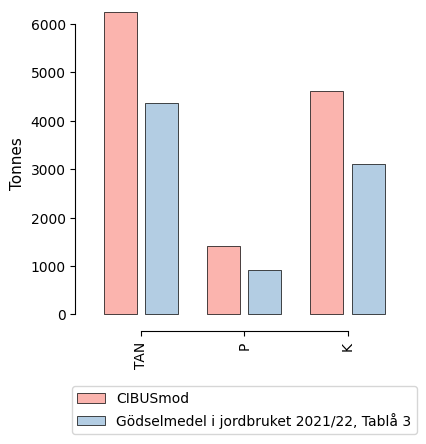

In [335]:

df_Cm = pd.concat([
    session.get_attr('w','organic_fertiliser_TAN',['treatment']).loc[(scn,year)],
    session.get_attr('w','organic_fertiliser_P',['treatment']).loc[(scn,year)],
    session.get_attr('w','organic_fertiliser_K',['treatment']).loc[(scn,year)]
]).rename('CIBUSmod')/1000
df_Cm.index = ['TAN','P','K']

# "Biogödsel totalt" according to statistics (Gödselmedel i jordbruket 2021/22, Tablå 3)
df_stat = pd.Series({
    'TAN' : 4370,
    'P' : 910,
    'K' : 3110
}).rename('Gödselmedel i jordbruket 2021/22, Tablå 3')

df = pd.concat([df_Cm,df_stat], axis=1)

fig, ax = plt.subplots(figsize=(4,4))
cm.plot.bar(df, stacked=False, cmap='Pastel1', ylabel='Tonnes', ax=ax)
plt.legend(bbox_to_anchor=(0.5, -0.2), loc='upper center', fontsize=10)
plt.show()

### Energy use

In [336]:
plot_data

treatment                                          anaerobic digestion
feedstock_type         feedstock_group                                
by-product waste       cereal by-products                     3.026477
                       dairy by-products                    171.609974
                       other by-products                    123.868639
                       slaughterhouse by-products           144.273257
crop feedstock         non-food                               2.271180
food waste, household  cereals                               74.843881
                       dairy                                 69.826026
                       eggs                                   6.442592
                       fruits                                11.616676
                       meat                                  31.712567
                       offals                                 0.337767
                       pulses                                 0.428764
                       sweeteners                            22.762049
                       treenuts                               0.021087
                       tubers                                46.092064
                       vegetable oils                         2.052443
                       vegetables                            58.009891
food waste, processing alcoholic beverages                    6.851689
                       cereals                               14.439454
                       dairy                                  3.237140
                       eggs                                   1.797672
                       fruits                                 0.175113
                       meat                                   1.066445
                       offals                                 0.018552
                       pulses                                 0.231196
                       sweeteners                             4.210360
                       tubers                                24.814674
                       vegetable oils                         0.393086
                       vegetables                             1.775148
food waste, retail     alcoholic beverages                   10.588759
                       cereals                                3.508188
                       dairy                                  1.831615
                       eggs                                   1.401262
                       fruits                                 3.900753
                       meat                                   6.897475
                       offals                                 0.073464
                       pulses                                 0.062171
                       sweeteners                             5.291479
                       treenuts                               0.003058
                       tubers                                11.718040
                       vegetable oils                         0.297604
                       vegetables                            19.479087
manure                 anaerobic digestion                  111.621335

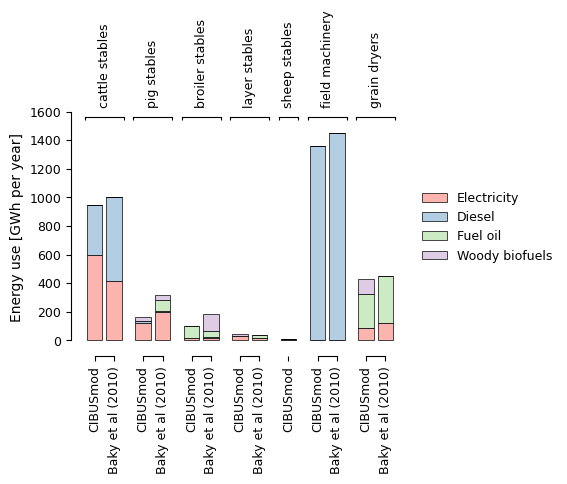

In [337]:
plot_data = (
    session.get_attr('A','energy_use',['species','breed','energy_source'])
    .loc[(scn,year)]
    .rename({'beef':'all','dairy':'all'})
    .groupby(['species','breed','energy_source'])
    .sum()
    .unstack()
    .loc[:,['Electricity','Diesel','Fuel oil','Woody biofuels']]
    /1000000
)
idx = pd.MultiIndex.from_tuples(
    [('cattle stables','CIBUSmod'),('pig stables','CIBUSmod'),
     ('broiler stables','CIBUSmod'),('layer stables','CIBUSmod'),
    ('sheep stables','CIBUSmod')],
    names=['category','source']
)
plot_data.index = idx
plot_data = plot_data.reindex(idx, fill_value=0)

plot_data.loc[('field machinery','CIBUSmod'),:] = (
    session.get_attr('C','energy_use',['activity','energy_source'])
    .loc[(scn,year),'field machinery'].rename({'Biodiesel':'Diesel'})
    .groupby('energy_source').sum()
    /1000000
)

plot_data.loc[('grain dryers','CIBUSmod'),:] = (
    session.get_attr('C','energy_use',['activity','energy_source'])
    .loc[(scn,year),['grain dryers', 'grain dryers auxiliary energy']]
    .groupby('energy_source').sum()
    /1000000
)

plot_data.loc[('cattle stables','Baky et al (2010)'),:]  = [  341+76,   118+466,      0,       0 ]
plot_data.loc[('pig stables','Baky et al (2010)'),:]     = [  134+66,       5+0,   79+0,    32+0 ]
plot_data.loc[('broiler stables','Baky et al (2010)'),:] = [      20,       0.6,     46,     116 ]
plot_data.loc[('layer stables','Baky et al (2010)'),:]   = [      19,       0.2,     19,       0 ]
plot_data.loc[('field machinery','Baky et al (2010)'),:] = [       0,      1449,      0,       0 ]
plot_data.loc[('grain dryers','Baky et al (2010)'),:] =    [     125,         0,      325,     0 ]

plot_data = plot_data.fillna(0)

fig, ax = plt.subplots(figsize=(4,3))
cm.plot.bar(plot_data, group_levels='category', ylabel='Energy use [GWh per year]', grouplabels_vertical=True, ax=ax, **bar_style)
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', fontsize=9, frameon=False)
plt.show()

plot_data.sort_index().style \
.format(precision=0, thousands=" ")

### Feed rations and use of by-products

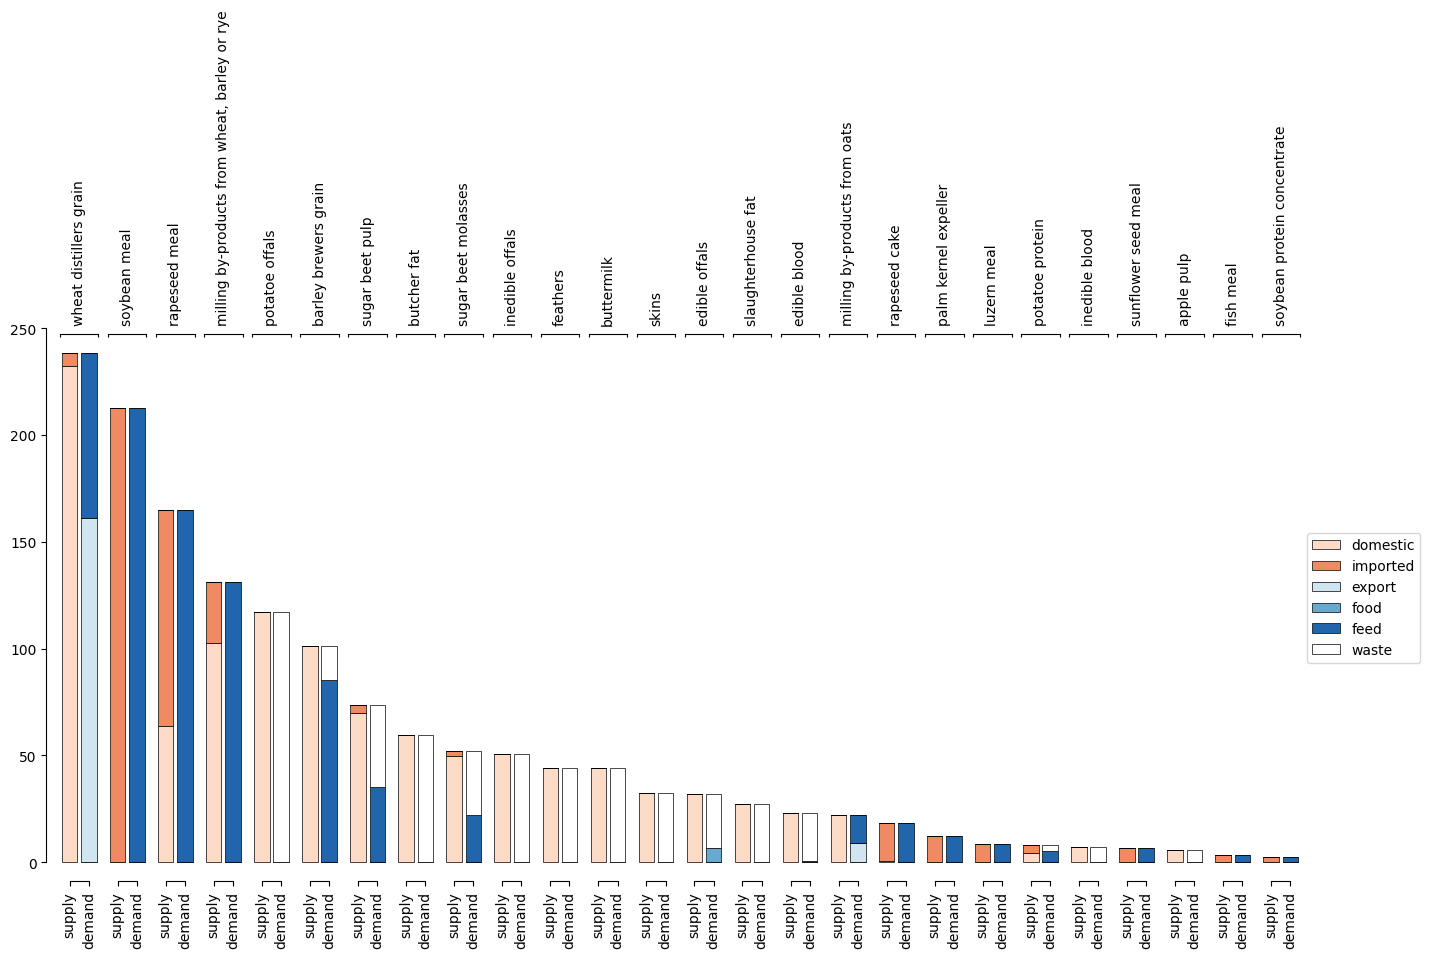

In [338]:
use = pd.concat([
    
    session.get_attr('D', 'by_prod_demand', ['by_prod', 'demand']).loc[(scn,year)].unstack(fill_value=0),
    
    session.get_attr('A', 'feed.by_product_demand', 'by_prod')
    .loc[(scn,year)]
    .rename('feed'),

    session.get_attr('D', 'by_prod_to_waste', 'by_prod').loc[(scn,year)]
    .rename('waste')
    
], axis=1).fillna(0).rename_axis('origin', axis=1)

supply = (
    session.get_attr('D', 'by_products', ['by_prod', 'origin'])
    .loc[(scn,year)]
    .unstack()
    .fillna(0)
)

plot_data = pd.concat([
    pd.concat({'supply': 
       supply
      }, names=['flow'], axis=1),
    
    pd.concat({'demand': 
       use
      }, names=['flow'], axis=1)
], axis=1).stack('flow').sort_index(level='flow', ascending=False).sort_index(level='by_prod', sort_remaining=False).fillna(0)/1000000

from matplotlib.colors import ListedColormap
colors = ['#fddbc7', '#ef8a62', '#d1e5f0', '#67a9cf', '#2166ac', '#ffffff']
cust_cmap = ListedColormap(name='X', colors=colors)

fig, ax = plt.subplots(1,1, figsize=(16,7))
ax, axgs = cm.plot.bar(
    plot_data.drop('whey'),
    ax=ax,
    cmap = cust_cmap,
    group_levels='by_prod',
    sort_groups=True,
    grouplabels_vertical=True
)
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.show()

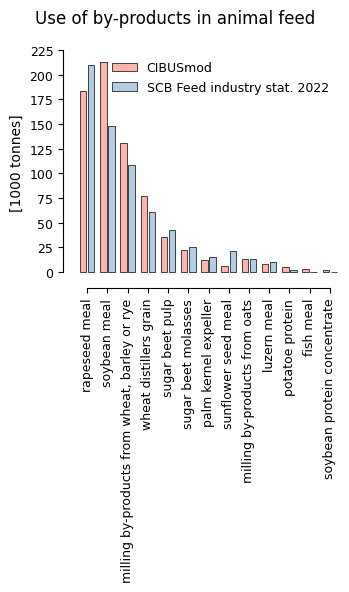

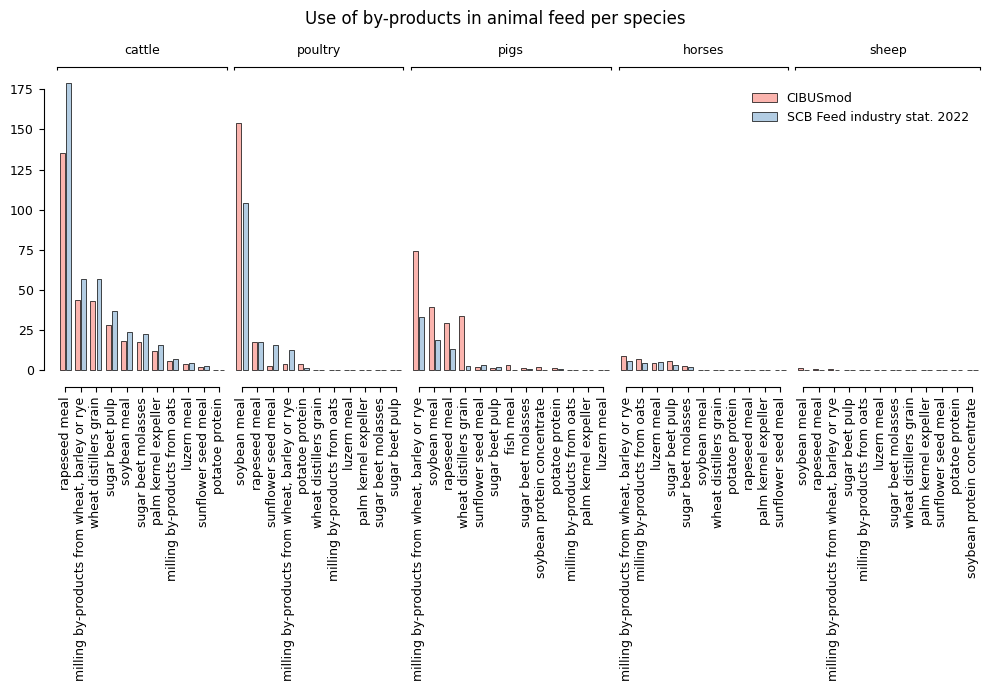

In [339]:
data = (
    session.get_attr('A','feed.by_product_demand')
    .loc[(scn,year)]
    .rename({'rapeseed cake' : 'rapeseed meal'})
    .groupby(['species','by_prod']).sum()
    .rename('CIBUSmod')
)/1000000

SCB_2022_feed_industry_stat = pd.Series({
    
    ('cattle','wheat distillers grain') : 56.803,
    ('cattle','rapeseed meal') : 178.628,
    ('cattle','milling by-products from wheat, barley or rye') : 57.085,
    ('cattle','sugar beet pulp') : 36.933,
    ('cattle','sugar beet molasses') : 22.689,
    ('cattle','soybean meal') : 23.656,
    ('cattle','palm kernel expeller') : 15.770,
    ('cattle','milling by-products from oats') : 7.277,
    ('cattle','luzern meal') : 4.850,
    ('cattle','sunflower seed meal') : 2.427,
    ('cattle','potatoe protein') : 0.166,

    ('horses','wheat distillers grain') : 0.199,
    ('horses','rapeseed meal') : 0.004,
    ('horses','milling by-products from wheat, barley or rye') : 5.745,
    ('horses','milling by-products from oats') : 4.646,
    ('horses','sugar beet pulp') : 3.495,
    ('horses','sugar beet molasses') : 1.812,
    ('horses','soybean meal') : 0.500,
    ('horses','palm kernel expeller') : 0.000,
    ('horses','luzern meal') : 5.355,
    ('horses','sunflower seed meal') : 0.000,
    ('horses','potatoe protein') : 0.016,

    ('pigs','wheat distillers grain') : 3.007, # A lot fed wet not through feed industry?
    ('pigs','rapeseed meal') : 13.057,
    ('pigs','milling by-products from wheat, barley or rye') : 33.011,
    ('pigs','milling by-products from oats') : 0.467,
    ('pigs','barley brewers grain') : np.nan, # Not in data, not going through feed industry??
    ('pigs','whey') : np.nan, # Not in data, not going through feed industry??
    ('pigs','sugar beet pulp') : 2.314,
    ('pigs','sugar beet molasses') : 0.767,
    ('pigs','soybean meal') : 19.069,
    ('pigs','palm kernel expeller') : 0.065,
    ('pigs','luzern meal') : 0.116,
    ('pigs','sunflower seed meal') : 3.581,
    ('pigs','potatoe protein') : 0.864,

    ('poultry','wheat distillers grain') : 0.489,
    ('poultry','rapeseed meal') : 17.796,
    ('poultry','milling by-products from wheat, barley or rye') : 12.408,
    ('poultry','milling by-products from oats') : 0.440,
    ('poultry','sugar beet pulp') : 0.000,
    ('poultry','sugar beet molasses') : 0.000,
    ('poultry','soybean meal') : 104.370,
    ('poultry','palm kernel expeller') : 0.000,
    ('poultry','luzern meal') : 0.236,
    ('poultry','sunflower seed meal') : 15.493,
    ('poultry','potatoe protein') : 1.202,
    
}).rename('SCB Feed industry stat. 2022').rename_axis(['species','by_prod'])

plot_data = pd.concat([data, SCB_2022_feed_industry_stat], axis=1)

# Drop whey and barley brewers grain as these are not going through feed industry???
plot_data = plot_data.drop('whey', level='by_prod')
plot_data = plot_data.drop('barley brewers grain', level='by_prod')

fig, ax = plt.subplots(1,1, figsize=(3.6,6))
ax, axgs = cm.plot.bar(plot_data.groupby('by_prod').sum(), ax=ax, stacked=False, ylabel='[1000 tonnes]', sort_xlabels=True, **bar_style)
plt.suptitle('Use of by-products in animal feed')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1,1, figsize=(10,7))
ax, axgs = cm.plot.bar(plot_data, ax=ax, stacked=False, group_levels='species', sort_xlabels=True, sort_groups=True, **bar_style)
plt.suptitle('Use of by-products in animal feed per species')
plt.tight_layout()
plt.show()



In [340]:
plot_data

CIBUSmod  \
species by_prod                                                     
cattle  luzern meal                                      3.699453   
        milling by-products from oats                    5.550362   
        milling by-products from wheat, barley or rye   43.540175   
        palm kernel expeller                            12.028047   
        potatoe protein                                  0.126841   
        rapeseed meal                                  135.487808   
        soybean meal                                    18.043138   
        sugar beet molasses                             17.484259   
        sugar beet pulp                                 28.169517   
        sunflower seed meal                              1.851061   
        wheat distillers grain                          43.325163   
horses  luzern meal                                      4.493039   
        milling by-products from oats                    7.356206   
        milling by-products from wheat, barley or rye    9.157475   
        potatoe protein                                  0.025856   
        sugar beet molasses                              2.927411   
        sugar beet pulp                                  5.578751   
pigs    fish meal                                        3.418110   
        milling by-products from wheat, barley or rye   74.032518   
        palm kernel expeller                             0.225189   
        potatoe protein                                  1.310214   
        rapeseed meal                                   29.252772   
        soybean meal                                    39.309051   
        soybean protein concentrate                      2.319420   
        sugar beet molasses                              1.564619   
        sugar beet pulp                                  1.217624   
        sunflower seed meal                              1.849555   
        wheat distillers grain                          33.927061   
poultry milling by-products from wheat, barley or rye    3.914193   
        potatoe protein                                  3.664094   
        rapeseed meal                                   17.684600   
        soybean meal                                   153.825061   
        sunflower seed meal                              2.888484   
sheep   luzern meal                                      0.083264   
        milling by-products from oats                    0.144010   
        milling by-products from wheat, barley or rye    0.619385   
        palm kernel expeller                             0.010685   
        potatoe protein                                  0.000224   
        rapeseed meal                                    0.644796   
        soybean meal                                     1.538671   
        soybean protein concentrate                      0.000061   
        sugar beet molasses                              0.073983   
        sugar beet pulp                                  0.189694   
        sunflower seed meal                              0.003722   
        wheat distillers grain                           0.047956   
horses  wheat distillers grain                                NaN   
        rapeseed meal                                         NaN   
        soybean meal                                          NaN   
        palm kernel expeller                                  NaN   
        sunflower seed meal                                   NaN   
pigs    milling by-products from oats                         NaN   
        luzern meal                                           NaN   
poultry wheat distillers grain                                NaN   
        milling by-products from oats                         NaN   
        sugar beet pulp                                       NaN   
        sugar beet molasses                                   NaN   
        palm kernel expeller                           

In [341]:
sel = 'cattle'

table_data = (
    session.get_attr('AnimalHerd', 'feed.consumption', ['species', 'breed', 'animal', 'feed']).loc[(scn,year)]
    .xs(sel)
    .unstack(['breed','animal'], fill_value=0)
    /
    session.get_attr('AnimalHerd', 'heads', ['species', 'breed', 'animal']).loc[(scn,year)]
    .xs(sel)
)

table_data.loc['total',:] = table_data.sum()

print('Unit: kg DM/head')
table_data.style \
.format(precision=1, thousands=" ", decimal=".",)

Unit: kg DM/head


In [342]:
table_data = (
    session.get_attr('AnimalHerd', 'feed.consumption', ['feed', 'species']).loc[(scn,year)]
    .unstack()
).fillna(0)/1000
table_data['total'] = table_data.sum(axis=1)
table_data.loc['total',:] = table_data.sum()

print('Unit: tonnes DM')
table_data.style \
.format(precision=0, thousands=" ", decimal=".",)

Unit: tonnes DM


species,cattle,horses,pigs,poultry,sheep,total
feed,,,,,,
barley,345 532,999,222 298,11 263,1 176,581 268
barley brewers grain,0,0,20 868,0,0,20 868
broad beans,14 049,0,46 265,0,64,60 378
fish meal,0,0,3 083,0,0,3 083
grazing,979 732,281 833,0,0,106 127,1 367 692
hay,0,738 710,0,0,0,738 710
"ley silage, 1st cut",1 419 056,0,0,0,29 468,1 448 524
"ley silage, regrowth",952 407,0,0,0,58 936,1 011 343
linseed,67,0,201,0,2,270


### Forage and pasture use per livestock system

In [343]:
table_data = session.get_attr('AnimalHerd', 'feed.demand', ['feed', 'species', 'breed', 'animal']).loc[(scn,year)]
table_data = (
    table_data
    .loc['grazing']
    /
    table_data
    .loc[['grazing', 'hay', 'ley silage, 1st cut', 'ley silage, regrowth', 'maize silage', 'other silage', 'straw']]
    .groupby(['species','breed','animal'])
    .sum()
    * 100
).fillna(0)

table_data.rename('% grazing').to_frame().style \
.format(precision=1, decimal=".",)

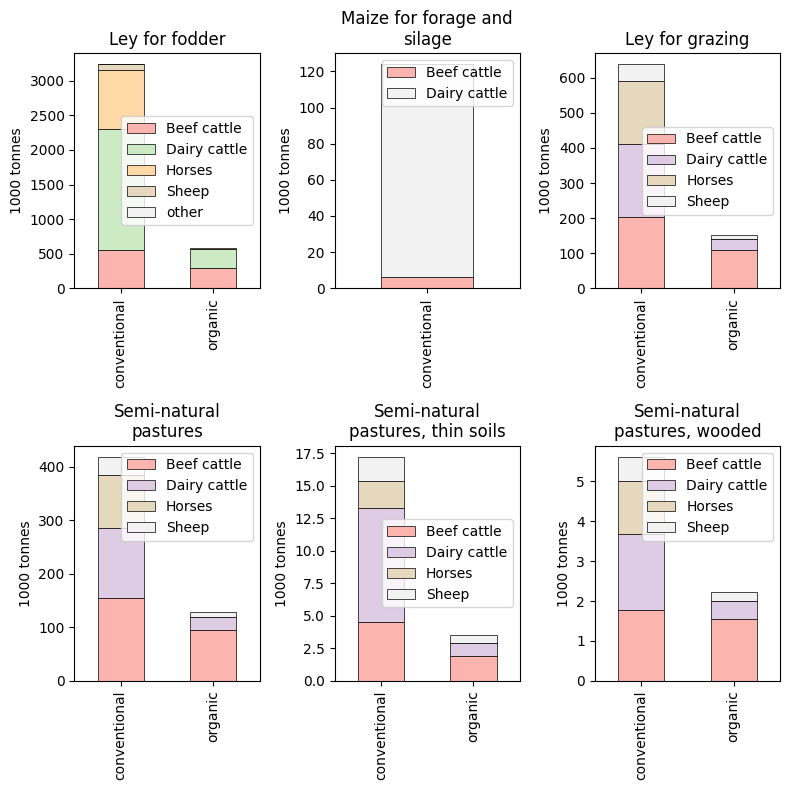

In [344]:
from textwrap import wrap
fig, axs = plt.subplots(2,3, figsize=(8,8))

for ax, cr in zip(
    axs.flatten(),
    ['Ley for fodder', 'Maize for forage and silage', 'Ley for grazing', 'Semi-natural pastures', 'Semi-natural pastures, thin soils', 'Semi-natural pastures, wooded']
):
    plot_data = (
        session.get_attr('c','production_per_use')
        .loc[(scn,year),cr]
        .groupby(['prod_system','demand'])
        .sum()
        .replace({0:np.nan})
        .dropna()
        .unstack()
    )/1000000
    plot_data.columns = ['Dairy cattle' if 'cattle, dairy' in c else 'Beef cattle' if 'cattle, beef' in c else 'Horses' if 'horses' in c else 'Sheep' if 'sheep' in c else 'other' for c in plot_data.columns]
    plot_data = plot_data.T.groupby(level=0).sum().T
    
    plot_data.plot(**pd_bar_style, stacked=True, ax=ax)
    ax.set_title('\n'.join(wrap(cr, 20)))
    ax.set_ylabel('1000 tonnes')
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

### Crop areas (deviation from x0)

#### Total crop areas

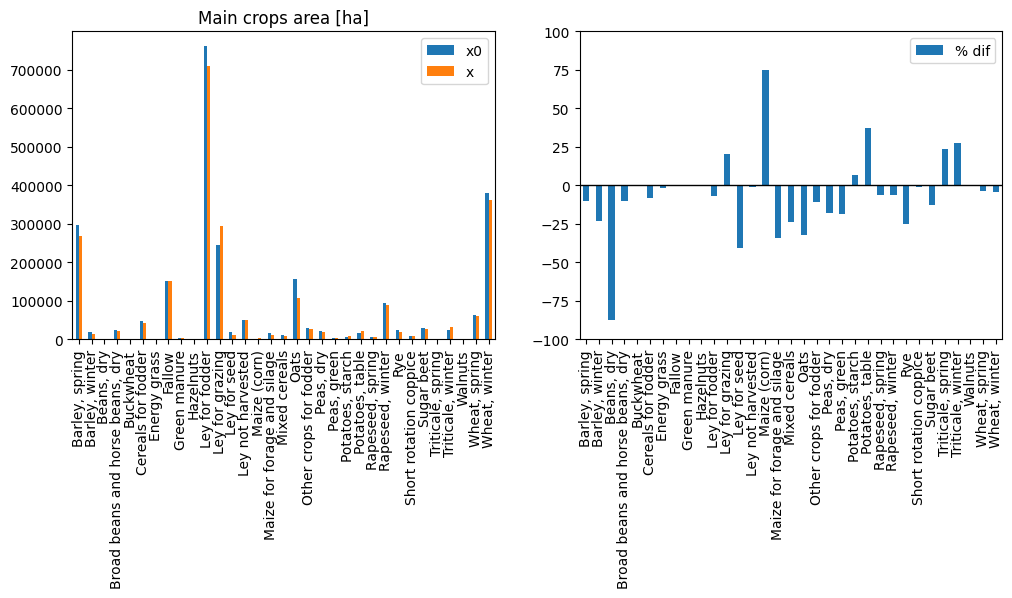

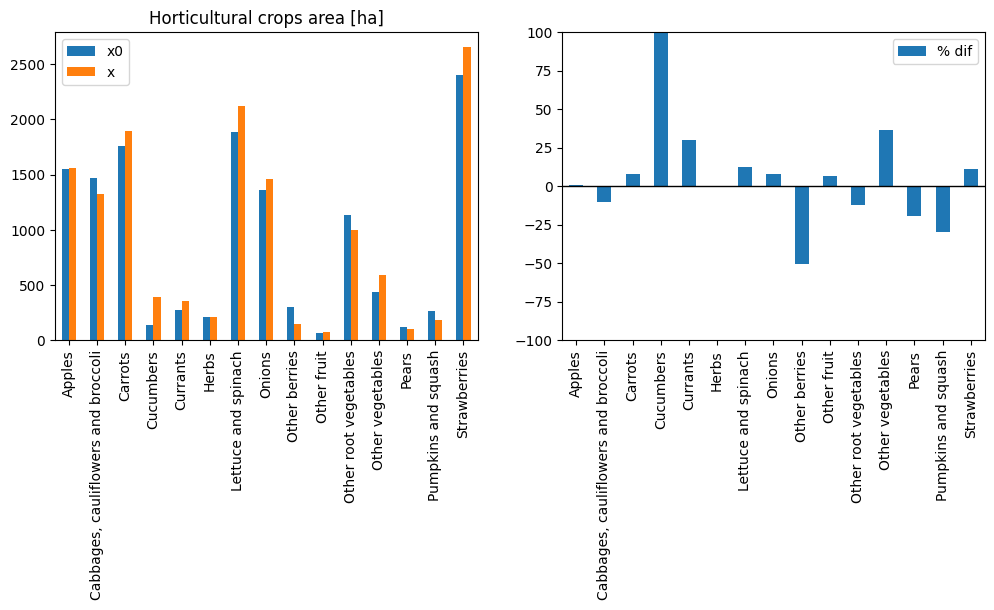

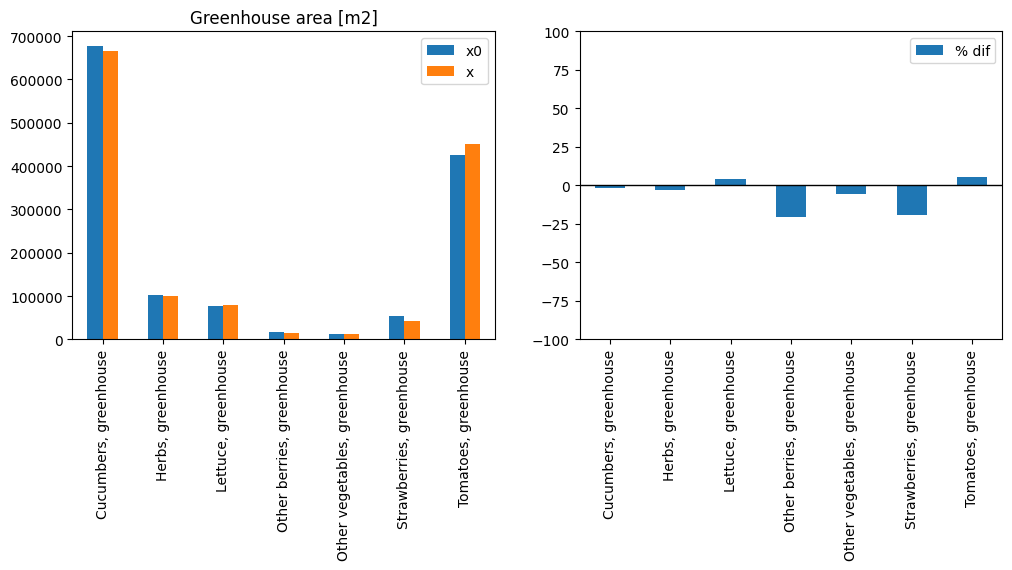

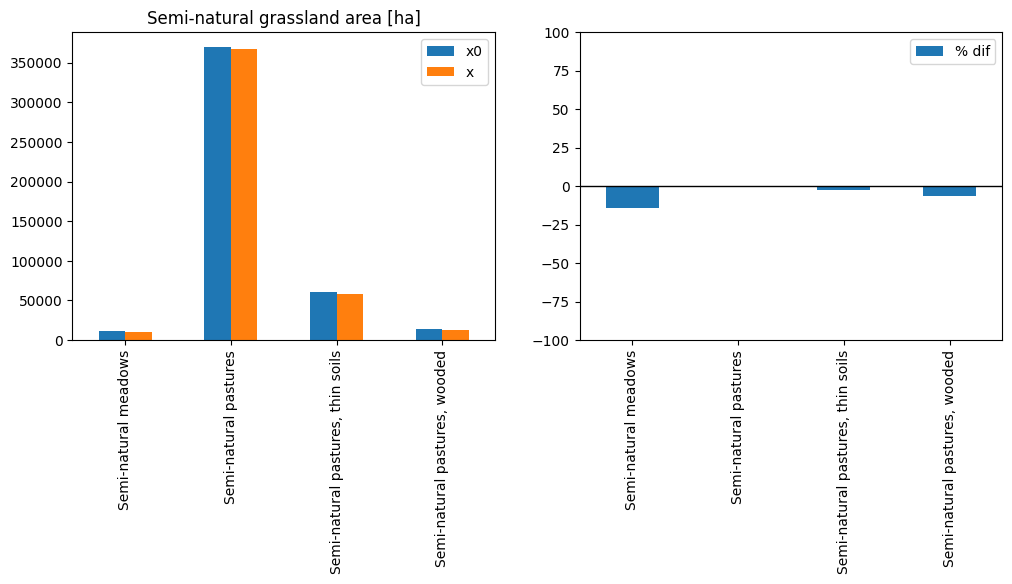

In [345]:
plot_data = pd.concat([
    session.get_attr('C','area',['crop']).loc[(scn,year)].rename('x'),
    session.get_attr('R','x0_crops',['crop']).loc[(scn,year)].rename('x0')
], axis=1)
plot_data['dif'] = plot_data.apply(lambda x:(x['x']-x['x0']), axis=1)
plot_data['% dif'] = plot_data.apply(lambda x:(x['x']-x['x0'])/x['x0']*100, axis=1)

cg_dict = cm.ParameterRetriever.get_rel('crop','crop_group2')
plot_data['cg'] = [cg_dict[c] for c in plot_data.index.get_level_values(0)]

hr = ['Vegetables, berries and fruit']
gh = ['Greenhouse crops']
sng = ['Semi-natural grasslands']
cr = list(set(cg_dict.values()) - set(hr) - set(gh) - set(sng))

plots = {
    'Main crops area [ha]' : cr,
    'Horticultural crops area [ha]' : hr,
    'Greenhouse area [m2]' : gh,
    'Semi-natural grassland area [ha]' : sng
}

for p in plots:
    fig, axs = plt.subplots(1,2, figsize=(12,4))
    
    ax=axs[0]
    plot_data[plot_data['cg'].isin(plots[p])].plot.bar(y=['x0','x'], ax=ax)
    ax.set_xlabel('')
    ax.set_title(p)
    
    ax=axs[1]
    plot_data[plot_data['cg'].isin(plots[p])].plot.bar(y='% dif', ax=ax)
    plt.axhline(y=0, c='black', lw=1)
    ax.set_xlabel('')
    ax.set_ylim(-100,100)
    
    plt.show()

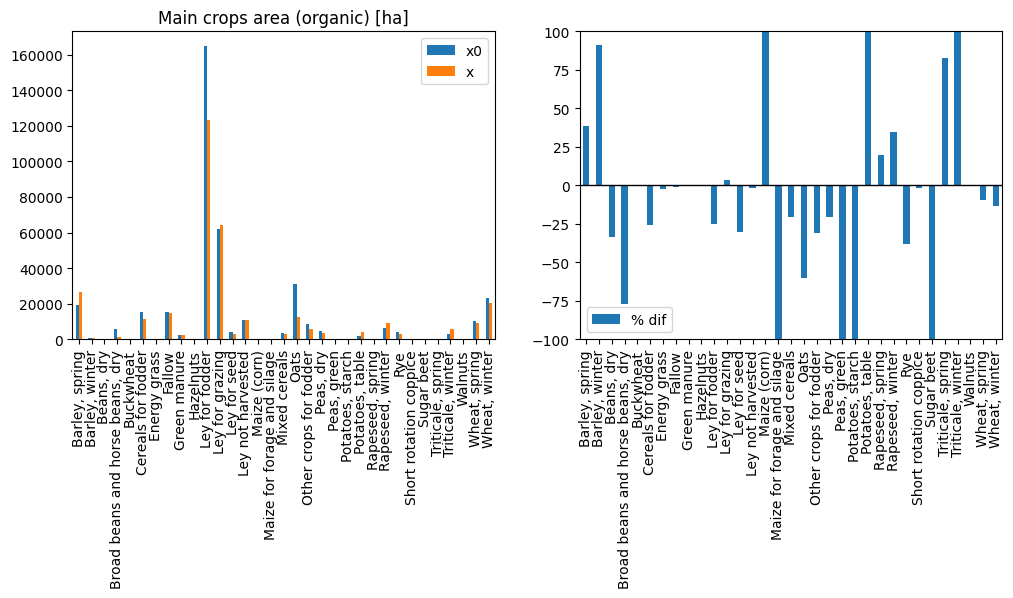

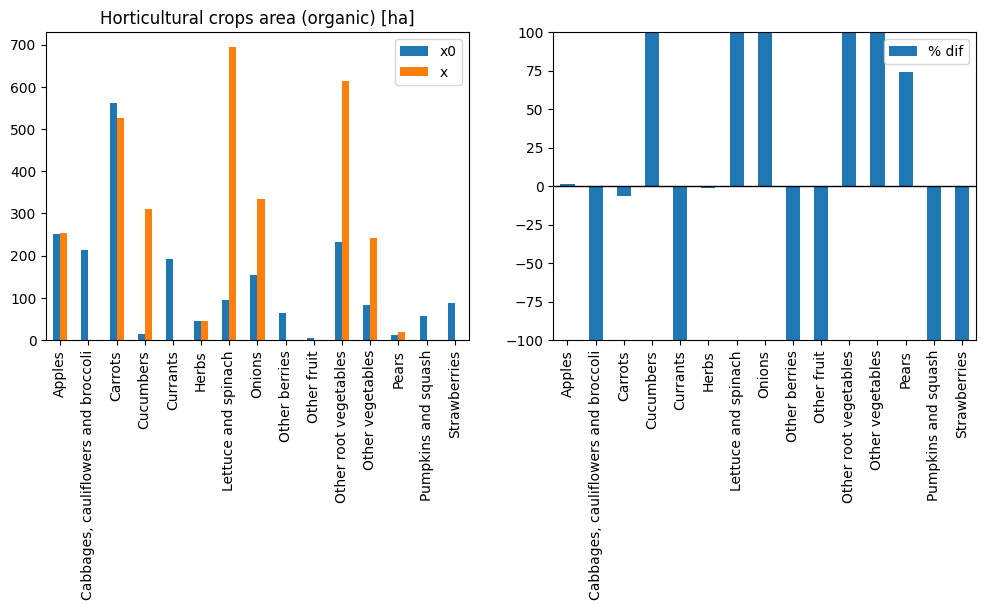

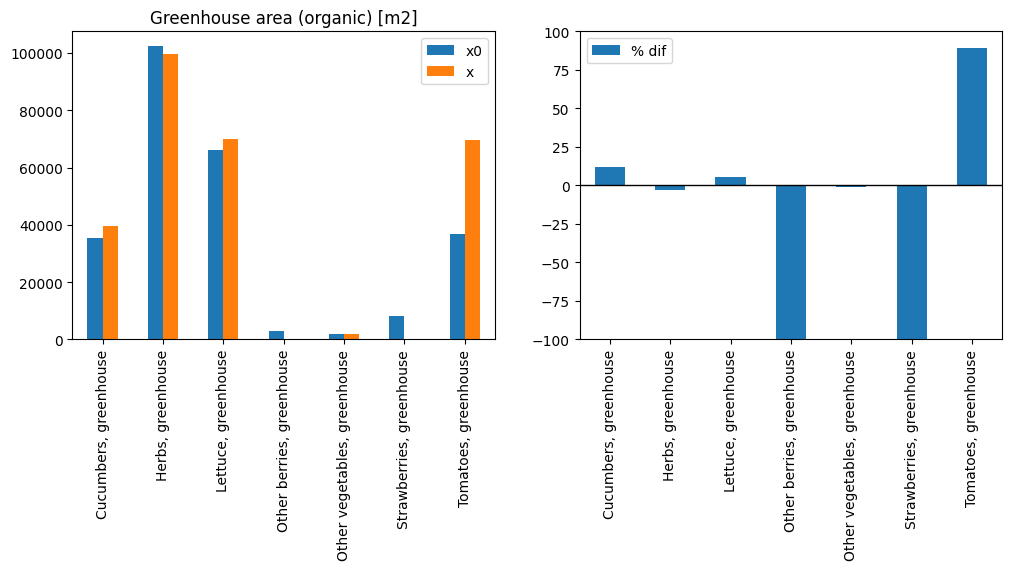

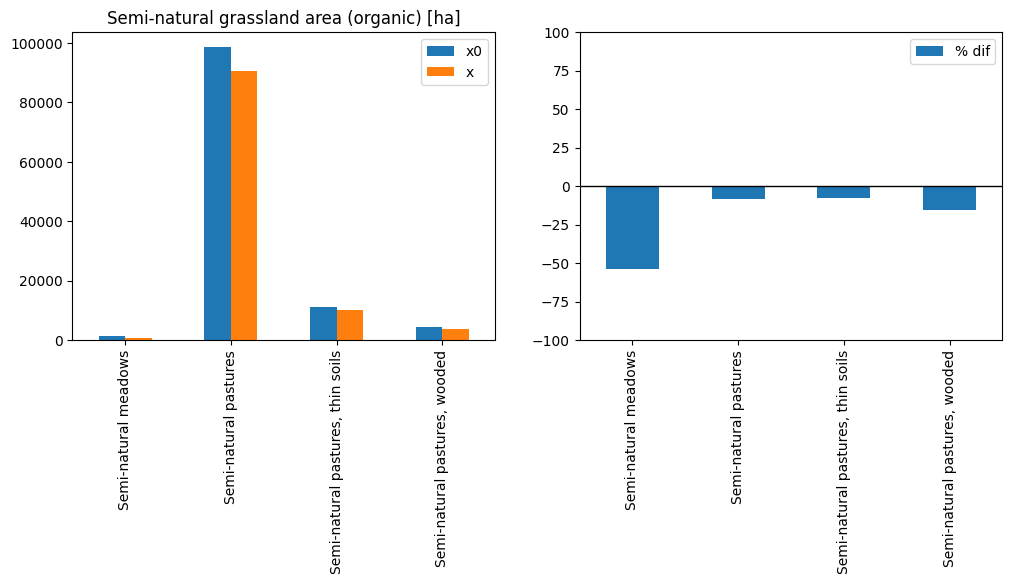

In [346]:
plot_data = pd.concat([
    session.get_attr('C','area',['crop','prod_system']).loc[(scn,year)].rename('x'),
    session.get_attr('R','x0_crops',['crop','prod_system']).loc[(scn,year)].rename('x0')
], axis=1)
plot_data['% dif'] = plot_data.apply(lambda x:(x['x']-x['x0'])/x['x0']*100 if x['x0']>0 else np.nan, axis=1)

cg_dict = cm.ParameterRetriever.get_rel('crop','crop_group2')
plot_data['cg'] = [cg_dict[c] for c in plot_data.index.get_level_values(0)]

hr = ['Vegetables, berries and fruit']
gh = ['Greenhouse crops']
sng = ['Semi-natural grasslands']
cr = list(set(cg_dict.values()) - set(hr) - set(gh) - set(sng))

plots = {
    'Main crops area (organic) [ha]' : cr,
    'Horticultural crops area (organic) [ha]' : hr,
    'Greenhouse area (organic) [m2]' : gh,
    'Semi-natural grassland area (organic) [ha]' : sng
}

plot_data = plot_data.xs('organic', level='prod_system')
for p in plots:
    fig, axs = plt.subplots(1,2, figsize=(12,4))
    
    ax=axs[0]
    plot_data[plot_data['cg'].isin(plots[p])].plot.bar(y=['x0','x'], ax=ax)
    ax.set_xlabel('')
    ax.set_title(p)
    
    ax=axs[1]
    plot_data[plot_data['cg'].isin(plots[p])].plot.bar(y='% dif', ax=ax)
    plt.axhline(y=0, c='black', lw=1)
    ax.set_xlabel('')
    ax.set_ylim(-100,100)
    
    plt.show()

#### Crop categories and some main crops per region

In [347]:
session.get_attr('C','area',['crop','region']).drop('base year (x0 crop areas)', level='scn').droplevel('year').rename(lambda x: x.replace('base year', 'x')).T

scn                             x   x (sp=0.2)   x (sp=0.8)
crop          region                                       
Apples        1011      25.273760    25.404426    24.961581
              111        0.000000     0.000000     0.000000
              1111     303.961649   310.104764   306.657570
              1112     154.756459   154.248085   151.988424
              112        6.153601     6.210530     6.112281
...                           ...          ...          ...
Wheat, winter 821     2311.120996  2266.471277  2390.186511
              831      355.144660   381.173979   163.382671
              911     1689.601751  1639.582181  1759.215754
              912     7905.995049  7967.003188  7975.975926
              913     1069.224121  1011.589107  1125.635556

[6254 rows x 3 columns]

In [348]:
plot_data

,x,x0,% dif,cg
crop,,,,
Apples,253.549731,250.185850,1.344553,"Vegetables, berries and fruit"
"Barley, spring",26618.533382,19200.602538,38.633844,Cereals
"Barley, winter",975.659611,509.981412,91.312779,Cereals
"Beans, dry",35.867354,54.057075,-33.649103,Other arable
"Broad beans and horse beans, dry",1379.497432,6036.982485,-77.149223,Other arable
Buckwheat,0.000084,NaN,NaN,Other arable
"Cabbages, cauliflowers and broccoli",0.000000,212.857852,-100.000000,"Vegetables, berries and fruit"
Carrots,525.930482,561.874348,-6.397136,"Vegetables, berries and fruit"
Cereals for fodder,11399.322339,15374.868004,-25.857430,Fodder crops


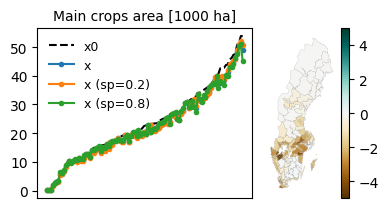

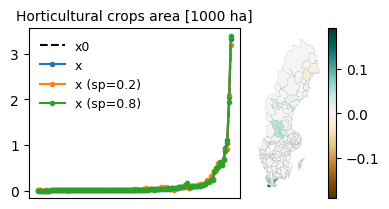

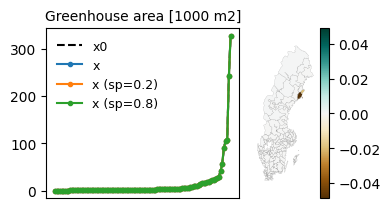

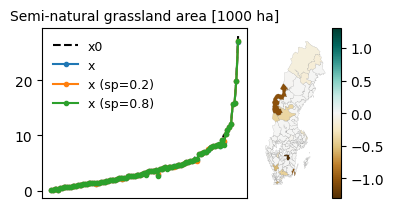

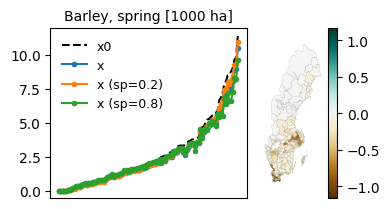

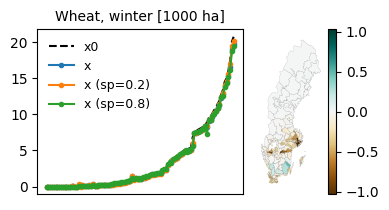

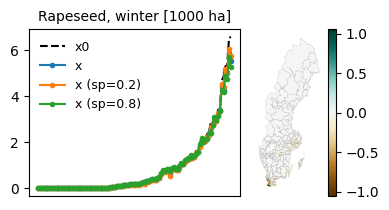

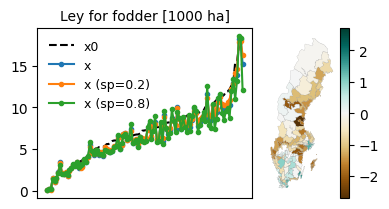

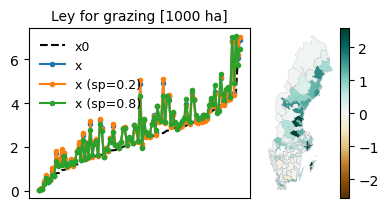

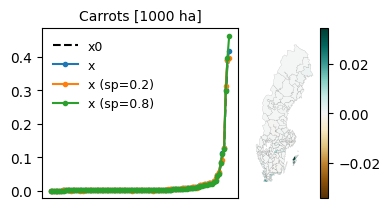

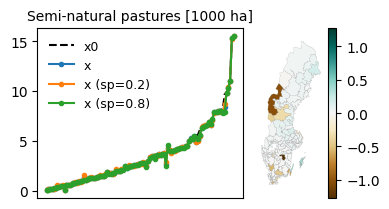

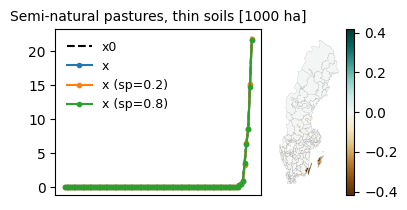

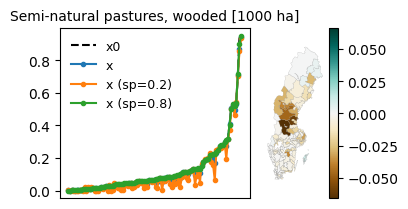

In [349]:
scns = ['base year', 'base year (sp=0.2)', 'base year (sp=0.8)']

plot_data_ = (
    pd.concat([
        session.get_attr('C','area',['crop','region']).droplevel('year').loc[scns].rename(lambda x: x.replace('base year', 'x')).T,
        session.get_attr('R','x0_crops',['crop','region']).loc[(scn,year)].rename('x0')
    ], axis=1)
)/1000

cg_dict = cm.ParameterRetriever.get_rel('crop','crop_group2')
plot_data_['cg'] = [cg_dict[c] for c in plot_data_.index.get_level_values('crop')]

hr = ['Vegetables, berries and fruit']
gh = ['Greenhouse crops']
sng = ['Semi-natural grasslands']
cr = list(set(cg_dict.values()) - set(hr) - set(gh) - set(sng))

plots = {
    'Main crops area [1000 ha]' : cr,
    'Horticultural crops area [1000 ha]' : hr,
    'Greenhouse area [1000 m2]' : gh,
    'Semi-natural grassland area [1000 ha]' : sng
}

for p in plots:

    # Crops
    plot_data = plot_data_.loc[plot_data_['cg'].isin(plots[p])].groupby('region').sum()
    plot_data['dif'] = (plot_data['x']-plot_data['x0'])
    plot_data.sort_values(by='x0', inplace=True)

    fig, axs = plt.subplots(1,2, figsize=(4,2.2), gridspec_kw={'width_ratios': [2, 0.8]})
    ax=axs[0]
    plot_data.plot(ax=ax, y='x0', kind='line', marker='', linestyle='--', color='black')
    plot_data.plot(ax=ax, y=[c.replace('base year','x') for c in scns], kind='line', marker='.', linestyle='-')
    # ax.set_yscale('log')
    ax.set_title(p, size=10)
    ax.set_xlabel('')
    ax.set_xticks([])
    ax.legend(bbox_to_anchor=(0, 1), loc='upper left', fontsize=9, frameon=False)

    ax=axs[1]
    lim = max(abs(plot_data['dif']))
    plot.map_from_series(
        plot_data['dif'].replace({np.inf:0, -np.inf:0}).fillna(0),
        ax=ax, vmin=-lim, vmax=lim, cmap='BrBG', edgecolor='grey'
    )
    ax.axis('off')
    
    plt.tight_layout()
    plt.show()

# Some main crops
crps = ['Barley, spring','Wheat, winter','Rapeseed, winter','Ley for fodder','Ley for grazing','Carrots','Semi-natural pastures','Semi-natural pastures, thin soils','Semi-natural pastures, wooded']
for crp in crps:
    plot_data = plot_data_.loc[crp].groupby('region').sum()
    plot_data['dif'] = (plot_data['x']-plot_data['x0'])
    plot_data.sort_values(by='x0', inplace=True)

    fig, axs = plt.subplots(1,2, figsize=(4,2.2), gridspec_kw={'width_ratios': [2, 0.8]})
    ax=axs[0]
    plot_data.plot(ax=ax, y='x0', kind='line', marker='', linestyle='--', color='black')
    plot_data.plot(ax=ax, y=[c.replace('base year','x') for c in scns], kind='line', marker='.', linestyle='-')
    # ax.set_yscale('log')
    ax.set_title(crp+' [1000 ha]', size=10)
    ax.set_xlabel('')
    ax.set_xticks([])
    ax.legend(bbox_to_anchor=(0, 1), loc='upper left', fontsize=9, frameon=False)

    ax=axs[1]
    lim = max(abs(plot_data['dif']))
    plot.map_from_series(
        plot_data['dif'].replace({np.inf:0, -np.inf:0}).fillna(0),
        ax=ax, vmin=-lim, vmax=lim, cmap='BrBG', edgecolor='grey'
    )
    ax.axis('off')

    plt.tight_layout()
    plt.show()

### Animal numbers (deviations from x0)

#### Total animal numbers

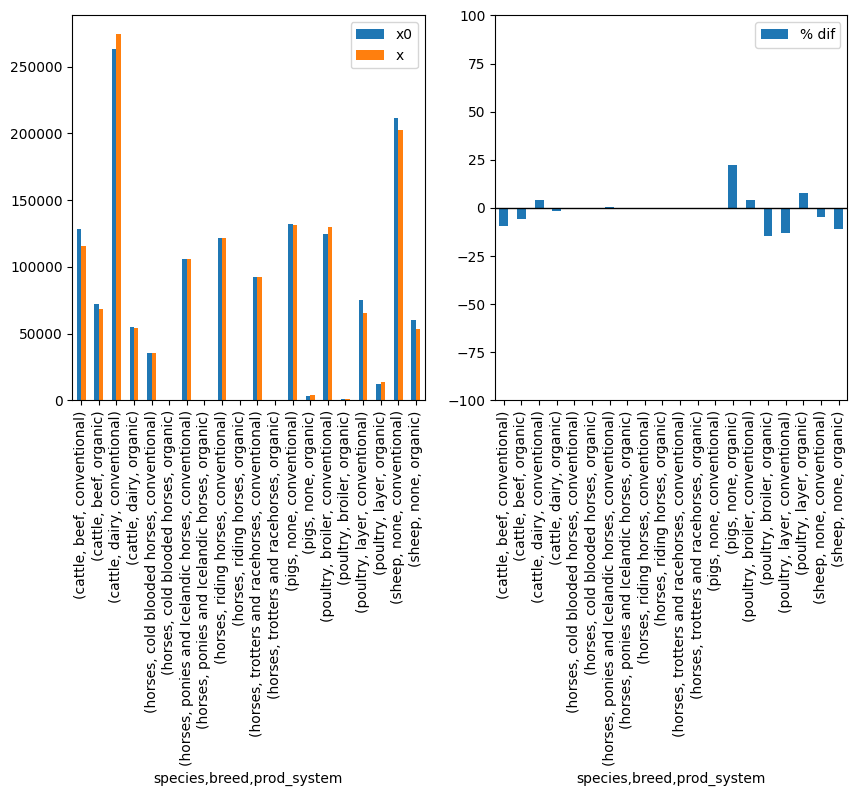

In [350]:
idx = pd.IndexSlice

plot_data_ = (
    pd.concat([
        session.get_attr('A','heads',['region','species','breed','prod_system','animal'])
        .droplevel('year')
        .rename(lambda x: x.replace('base year','x'))
        .T
        .loc[idx[:,:,:,:,[
                'cows',
                'sows','gilts',
                'broodmares','low-performing horses','medium-performing horses','young horses',
                'broilers',
                'laying hens (16-28 weeks)','laying hens (29-59 weeks)','laying hens (>59 weeks)','breeding hens and roosters',
                'ewes','rams'
            ]],:]
        .groupby(['region','species','breed','prod_system'])
        .sum()
        ,
        session.get_attr('R','x0_animals',['region','species','breed','prod_system']).loc[(scn,year)]
        .rename('x0')
    ], axis=1)
)

# Adjust poultry to 100 heads
plot_data_ = \
plot_data_.mul(np.where(plot_data_.index.get_level_values('species')=='poultry',1/100,1), axis=0)

plot_data = plot_data_.groupby(['species','breed','prod_system']).sum()
plot_data['% dif'] = (plot_data['x']-plot_data['x0'])/plot_data['x0']*100

fig, axs = plt.subplots(1,2, figsize=(10,5))
plot_data.plot.bar(y=['x0','x'], ax=axs[0])
plot_data.plot.bar(y='% dif', ax=axs[1])
plt.axhline(y=0, c='black', lw=1)
axs[1].set_ylim(-100,100)
plt.show()

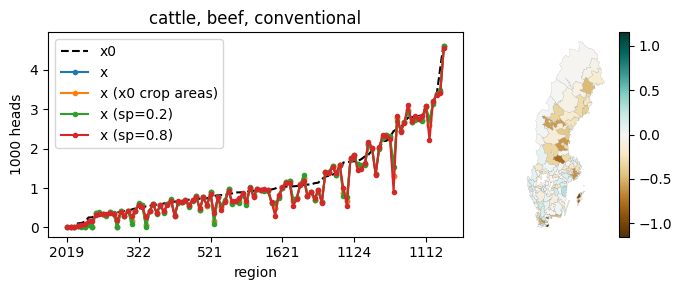

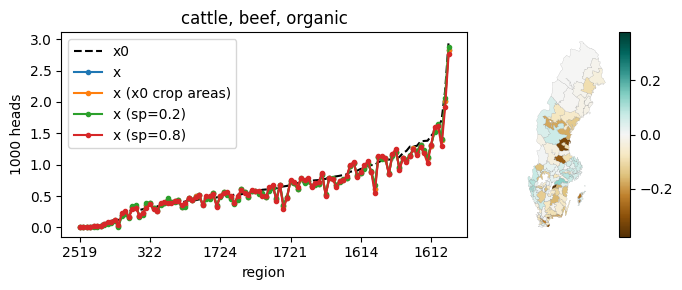

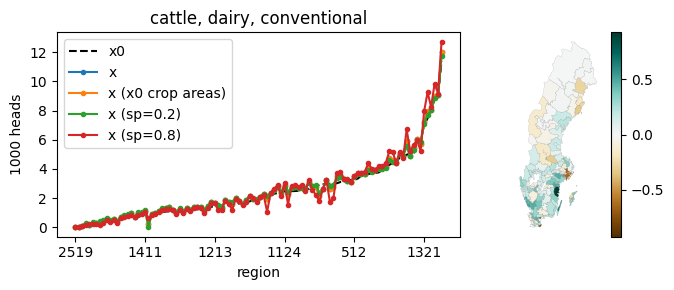

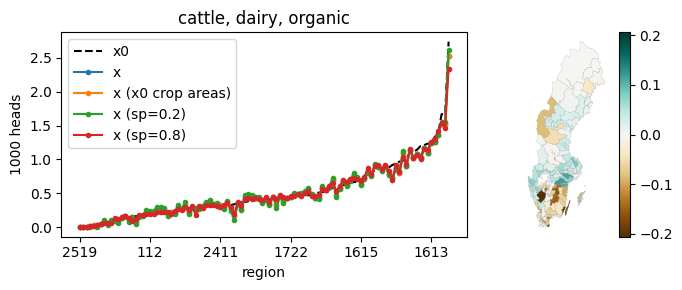

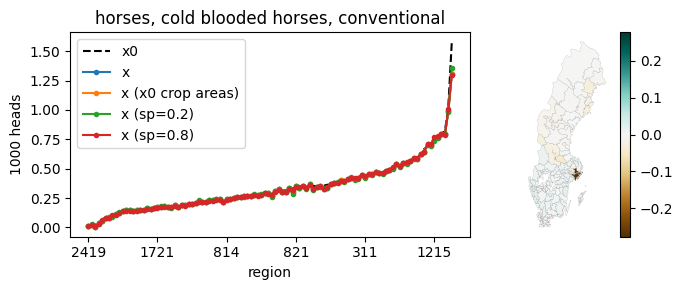

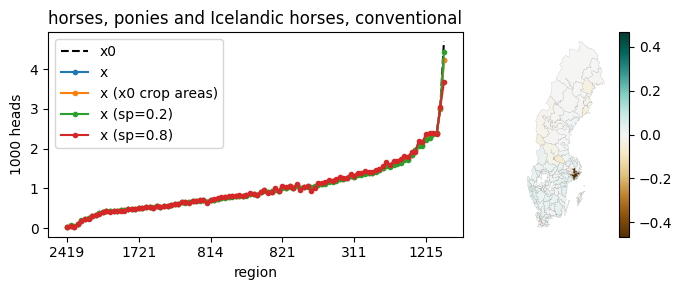

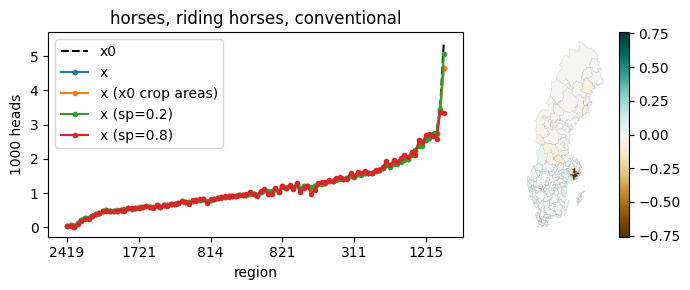

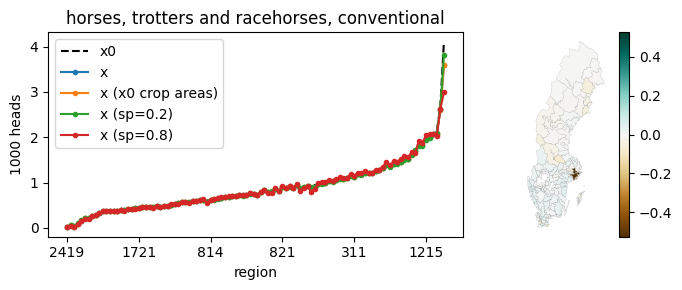

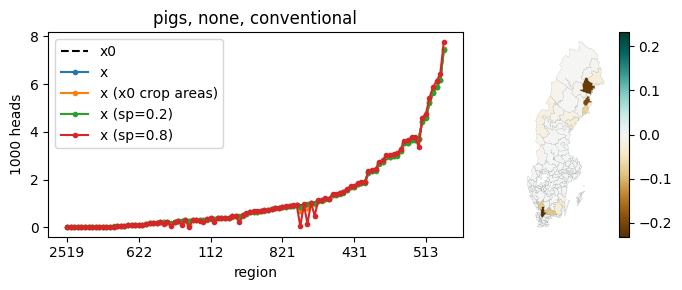

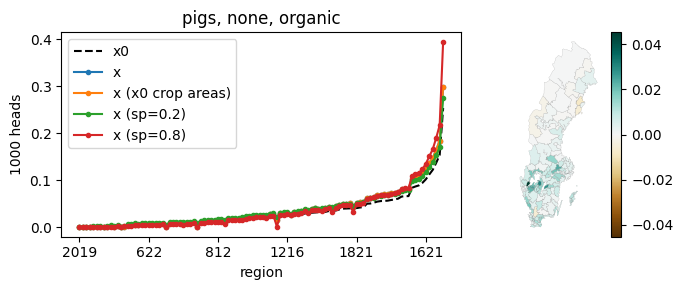

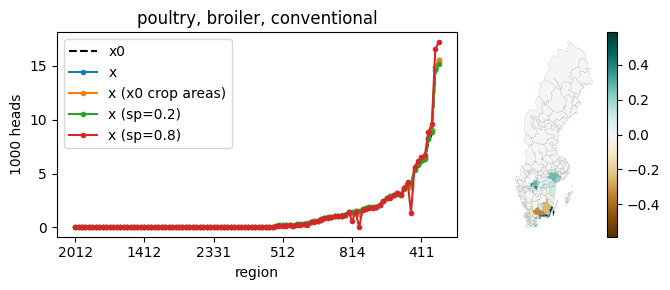

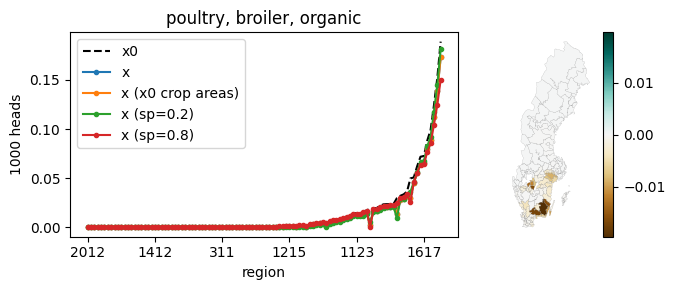

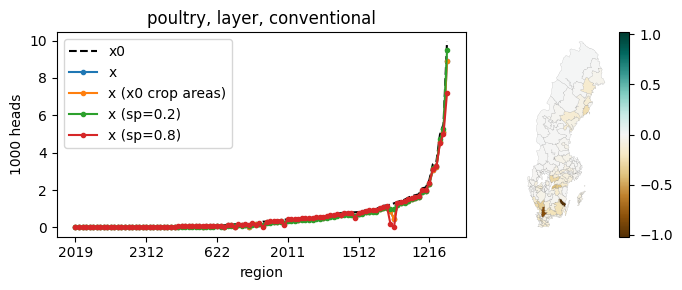

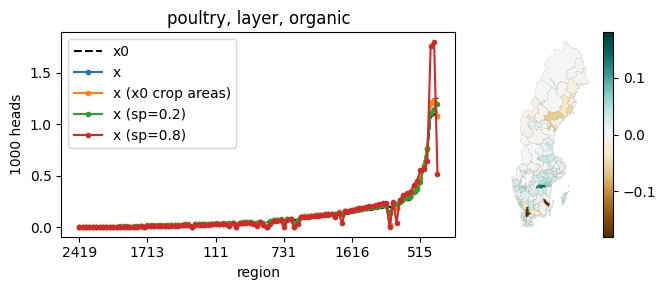

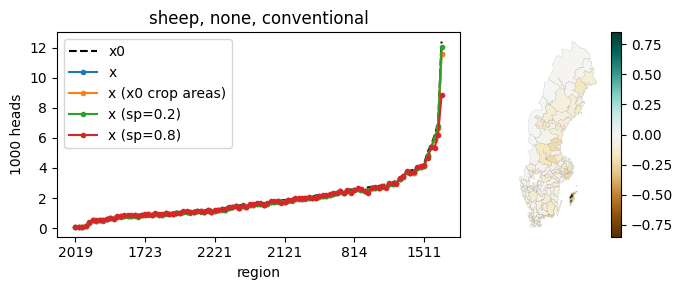

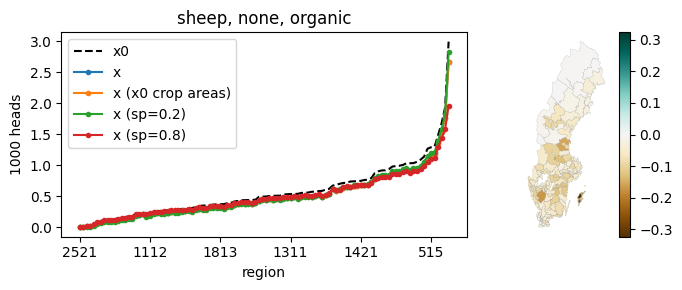

In [351]:
for idx in plot_data_.index.droplevel('region').unique():
    
    if 'horses' in idx and 'organic' in idx:
        continue
        
    plot_data = plot_data_.xs(idx, level=('species','breed','prod_system')).copy()/1000
    plot_data['dif'] = (plot_data['x']-plot_data['x0'])
    plot_data.sort_values(by='x0', inplace=True)

    fig, axs = plt.subplots(1,2, figsize=(7,3), gridspec_kw={'width_ratios': [2, 1]})
    ax=axs[0]
    plot_data.plot(ax=ax, y='x0', kind='line', marker='', linestyle='--', color='black')
    plot_data.plot(ax=ax, y=[c.replace('base year','x') for c in session.scenarios('has output')], kind='line', marker='.', linestyle='-')
    # ax.set_yscale('log')
    ax.set_title(', '.join(idx))
    ax.set_ylabel('1000 heads')

    ax=axs[1]
    lim = max(abs(plot_data['dif']))
    plot.map_from_series(
        plot_data['dif'].replace({np.inf:0, -np.inf:0}).fillna(0),
        ax=ax, vmin=-lim, vmax=lim, cmap='BrBG', edgecolor='grey'
    )
    ax.axis('off')
    
    plt.tight_layout()
    plt.show()

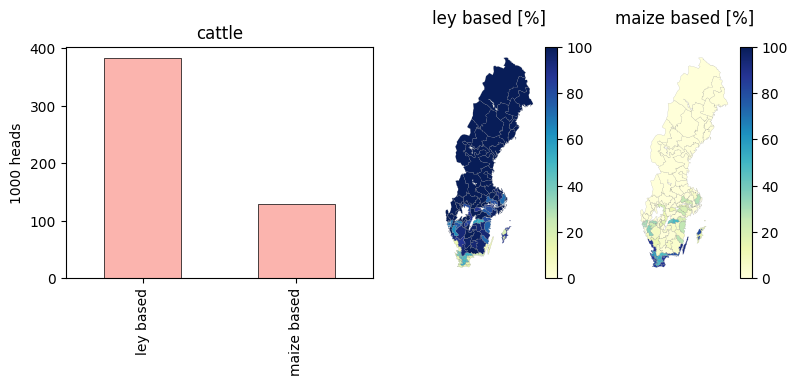

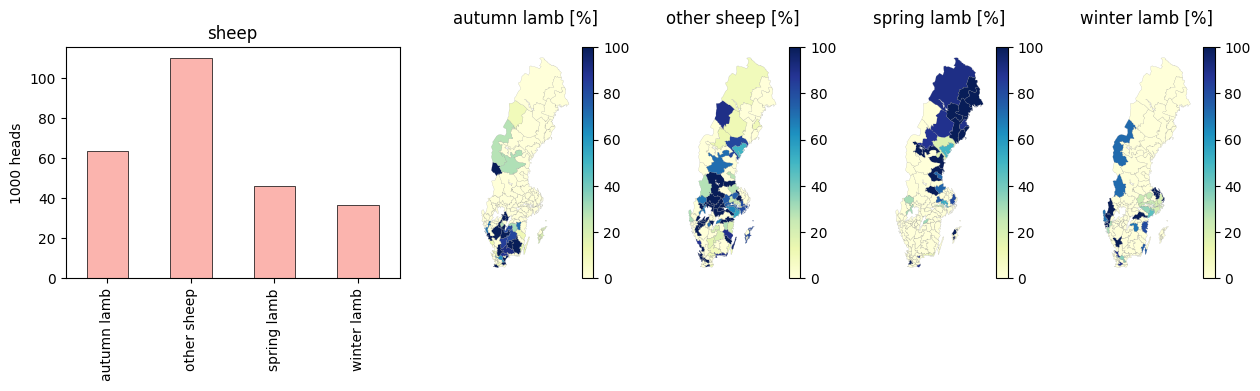

In [352]:
idx = pd.IndexSlice
plot_data = (
    session.get_attr('A','heads',['species','sub_system','region','animal']).loc[(scn,year)]
    .loc[idx[:,:,:,[
            'cows',
            'sows','gilts',
            'broodmares','low-performing horses','medium-performing horses','young horses',
            'broilers',
            'laying hens (16-28 weeks)','laying hens (29-59 weeks)','laying hens (>59 weeks)','breeding hens and roosters',
            'ewes','rams'
        ]]]
    .groupby(['species','sub_system','region'])
    .sum()
)/1000


for sp in plot_data.index.get_level_values('species').unique():
    plot_data_ = plot_data.xs(sp)
    sss = plot_data_.index.get_level_values('sub_system').unique()
    n_ss = len(sss)
    if n_ss>1:
        fig, axs = plt.subplots(1, 1+n_ss, figsize=(3+3*n_ss,3), gridspec_kw={'width_ratios': [2] + [1]*n_ss})
        ax=axs[0]
        plot_data_.groupby('sub_system').sum().plot(**pd_bar_style, ax=ax)
        ax.set_xlabel('')
        ax.set_ylabel('1000 heads')
        ax.set_title(sp)
        
        map_data = plot_data_.groupby('region').transform(lambda x: x/x.sum() * 100)
        for ax,ss in zip(axs[1::],sss):
            plot.map_from_series(
                map_data.xs(ss),
                ax=ax,
                vmin=0,
                vmax=100,
                **map_style
            )
            ax.set_title(ss + ' [%]')
            ax.axis('off')
            
        plt.show()

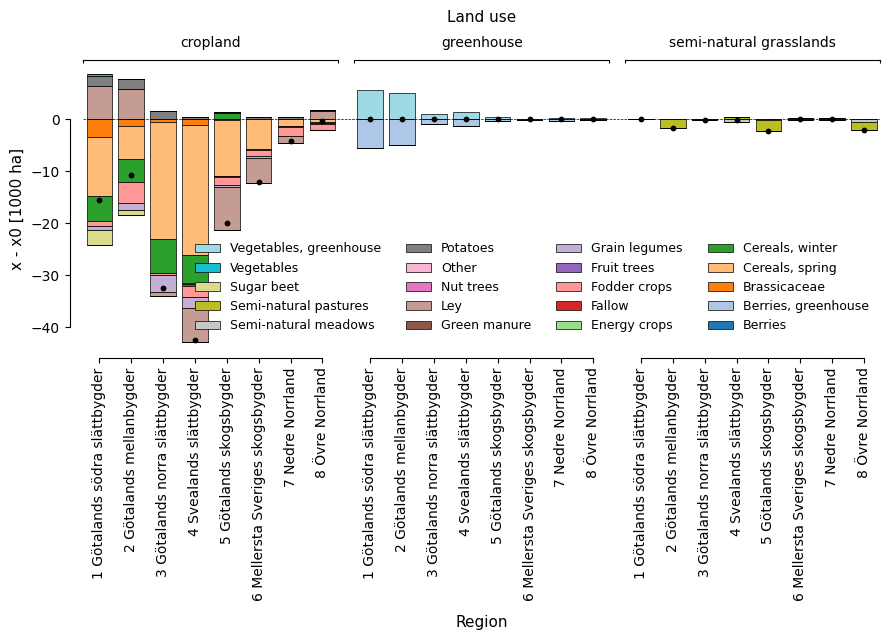

In [353]:
fig = plt.figure(figsize=(9,6.5))
data = (
    (session.get_attr('cr','area',{'crop':['land_use','crop_group'],'region':'po8'}).iloc[0] -
    session.get_attr('r','x0_crops',{'crop':['land_use','crop_group'],'region':'po8'}).iloc[0]) / 1000
).unstack('crop_group')
ax = plot.bar(data, stacked=True, group_levels='land_use', sort_xlabels=False, sort_groups=False, cmap='tab20', grouptitle='Land use', xlabel='Region', ylabel='x - x0 [1000 ha]')

plt.tight_layout()
plt.show()

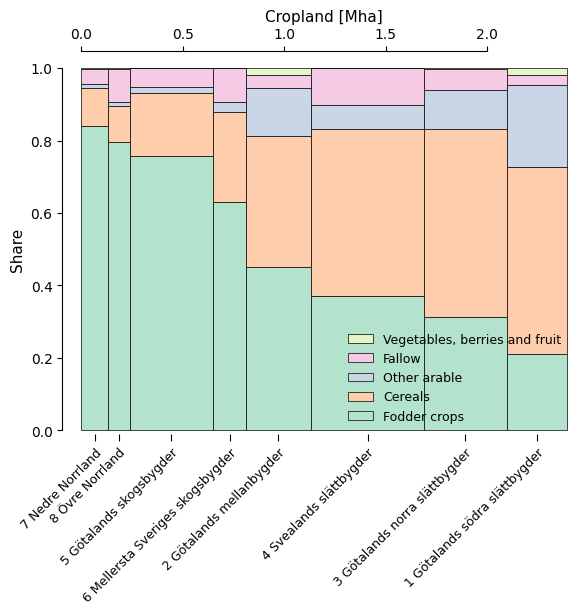

In [354]:
data = session.get_attr('c','area',{'crop':['land_use','crop_group2'],'region':'po8'}).iloc[0].loc['cropland'].unstack('crop_group2') / 1000000
ax = plot.marimekko(data, xlabel='Cropland [Mha]', ylabel='Share', cmap='Pastel2')
plt.show()

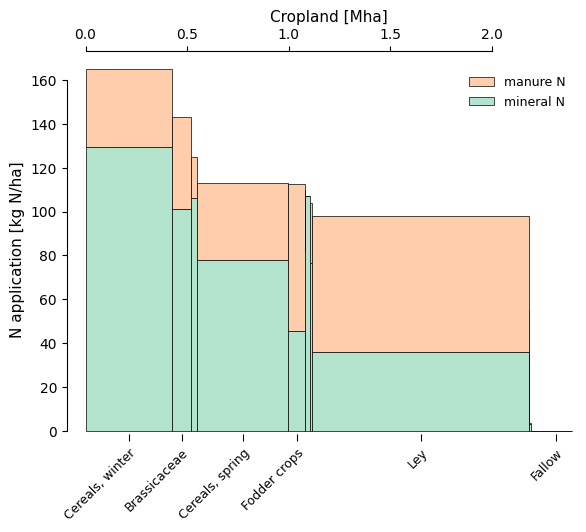

In [355]:
data = pd.concat([
    session.get_attr('c','fertiliser.mineral_N',{'crop':['land_use','crop_group']}).iloc[0]
    .div(session.get_attr('c','area',{'crop':['land_use','crop_group']}).iloc[0], axis=0).rename('mineral N'),
    session.get_attr('c','fertiliser.manure_N',{'crop':['land_use','crop_group']}).iloc[0]
    .div(session.get_attr('c','area',{'crop':['land_use','crop_group']}).iloc[0], axis=0).rename('manure N'),
    session.get_attr('c','area',{'crop':['land_use','crop_group']}).iloc[0].rename('x') / 1000000
], axis=1).fillna(0).loc['cropland']
plot.marimekko(data, x_column='x', xlabel='Cropland [Mha]', ylabel='N application [kg N/ha]', cmap='Pastel2')
plt.show()

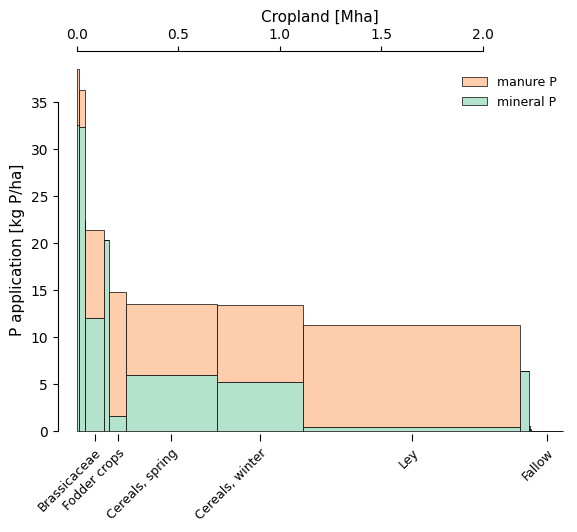

In [356]:
data = pd.concat([
    session.get_attr('c','fertiliser.mineral_P',{'crop':['land_use','crop_group']}).iloc[0]
    .div(session.get_attr('c','area',{'crop':['land_use','crop_group']}).iloc[0], axis=0).rename('mineral P'),
    session.get_attr('c','fertiliser.manure_P',{'crop':['land_use','crop_group']}).iloc[0]
    .div(session.get_attr('c','area',{'crop':['land_use','crop_group']}).iloc[0], axis=0).rename('manure P'),
    session.get_attr('c','area',{'crop':['land_use','crop_group']}).iloc[0].rename('x') / 1000000
], axis=1).fillna(0).loc['cropland']
plot.marimekko(data, x_column='x', xlabel='Cropland [Mha]', ylabel='P application [kg P/ha]', cmap='Pastel2', categorylabels_threshold=0.02, categorylabels_fontsize=9)
plt.show()

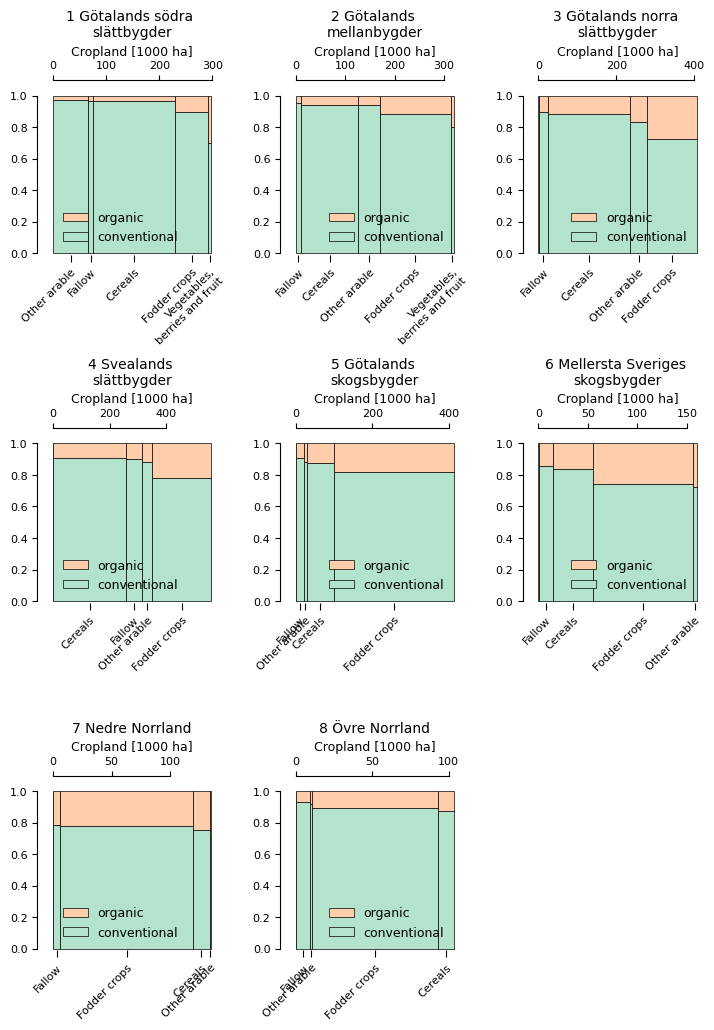

In [357]:
data = session.get_attr('c','area',{'crop':['land_use','crop_group2'], 'region':'po8', 'prod_system':None}).iloc[0].loc['cropland'].unstack()/1000
fig, axs = plot.subplots(data, index='po8', plot_fn=plot.marimekko, size=(2.5,3.5), cmap='Pastel2', title_fontsize=10, categorylabels_threshold=0.01,
                         categorylabels_wrap=18, categorylabels_fontsize=8, xlabel='Cropland [1000 ha]', xlabel_fontsize=9, ticklabels_fontsize=8)
plt.tight_layout(pad=2)
plt.show()

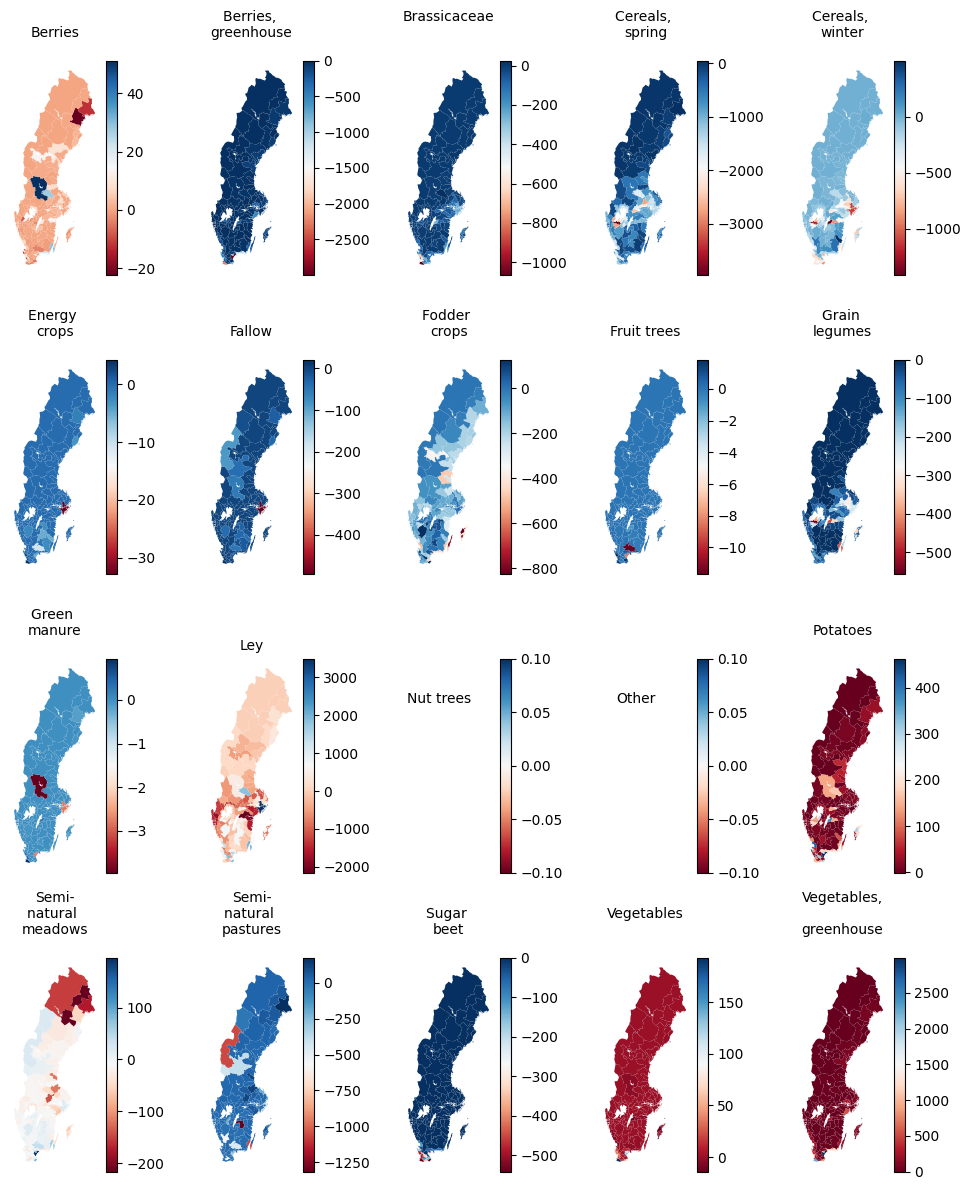

In [358]:
data = (session.get_attr('c','area',{'crop':'crop_group','region':None}) - session.get_attr('r','x0_crops',{'crop':'crop_group','region':None})).iloc[0]

fig, axs = plot.subplots(data, index='crop_group', title_fontsize=10, size=(2,3), plot_fn=plot.map_from_series, cmap='RdBu')
for ax in axs.flatten():
    ax.axis('off')
plt.tight_layout()
plt.show()